<a href="https://colab.research.google.com/github/eduardo-illueca/icg-project/blob/main/HC_Echo_PCG.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

This notebook processes echocardiography signals as well as PCG signals, then we compare with ICG and ECG.

# Load Data

In [ ]:
import os
import pandas as pd
from google.colab import drive
import scipy.io as sio
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import savgol_filter
import matplotlib.pyplot as plt
from scipy.signal import savgol_filter
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler  # Z-score scaler

We load the data from Google Drive.

In [ ]:
# mount Google Drive
drive.mount('/content/drive')
dir_path = "/content/drive/MyDrive/TFG/Data_HeartCycle/59146237"

file_path = '/content/drive/MyDrive/TFG/Data_HeartCycle/59146237/59146237_s0000010.mat'
data_hc = sio.loadmat(file_path)
print(data_hc.keys())

header = data_hc['__header__']
#print(header) #b'MATLAB 5.0 MAT-file, Platform: PCWIN, Created on: Thu Mar 12 19:36:31 2009'

version = data_hc['__version__']
#print(version) # 1.0

globals = data_hc['__globals__']
#print(globals) # []

measures = data_hc['measure']
#print(measures)

print(type(measures))        # ndarray
print(measures.shape)       # 30 rows and 5 columns

rows, cols = measures.shape # measures is a 30x5 ndarray
# to see which signals we have
for i in range(rows):
    for j in range(cols):
        try:
            label = measures[i, j]['label'][0, 0]
            print(f"{label} = measures[{i},{j}]")
        except:
            continue

print(measures[1,1]['label'][0]) #ICG

Mounted at /content/drive
dict_keys(['__header__', '__version__', '__globals__', 'measure'])
<class 'numpy.ndarray'>
(30, 5)
['Event'] = measures[0,0]
['ECG'] = measures[0,1]
['ECG'] = measures[0,2]
['ECG'] = measures[0,3]
['ECG'] = measures[0,4]
['SPO2'] = measures[1,0]
['IMP'] = measures[1,1]
['PCG'] = measures[1,2]
['ECHO'] = measures[1,3]
['PPG'] = measures[1,4]
['O/C'] = measures[2,0]
['RPEAKS'] = measures[2,1]
['RPEAKS'] = measures[2,2]
['RPEAKS'] = measures[2,3]
['RPEAKS'] = measures[2,4]
['Load'] = measures[3,0]
['AVO'] = measures[3,1]
['AVO'] = measures[3,2]
['AVO'] = measures[3,3]
['AVO'] = measures[3,4]
['HPD'] = measures[4,0]
['PPEjec'] = measures[4,1]
['PEP'] = measures[4,2]
['PEP'] = measures[4,3]
['PEP'] = measures[4,4]
['DC'] = measures[5,0]
['AVC'] = measures[5,1]
['AVC'] = measures[5,2]
['AVC'] = measures[5,3]
['AVC'] = measures[5,4]
['TFC'] = measures[6,0]
['LVET'] = measures[6,1]
['LVET'] = measures[6,2]
['LVET'] = measures[6,3]
['LVET'] = measures[6,4]
['FC'] = mea

# Signal Preprocessing (ICG, ECG)

## ICG Preprocessing

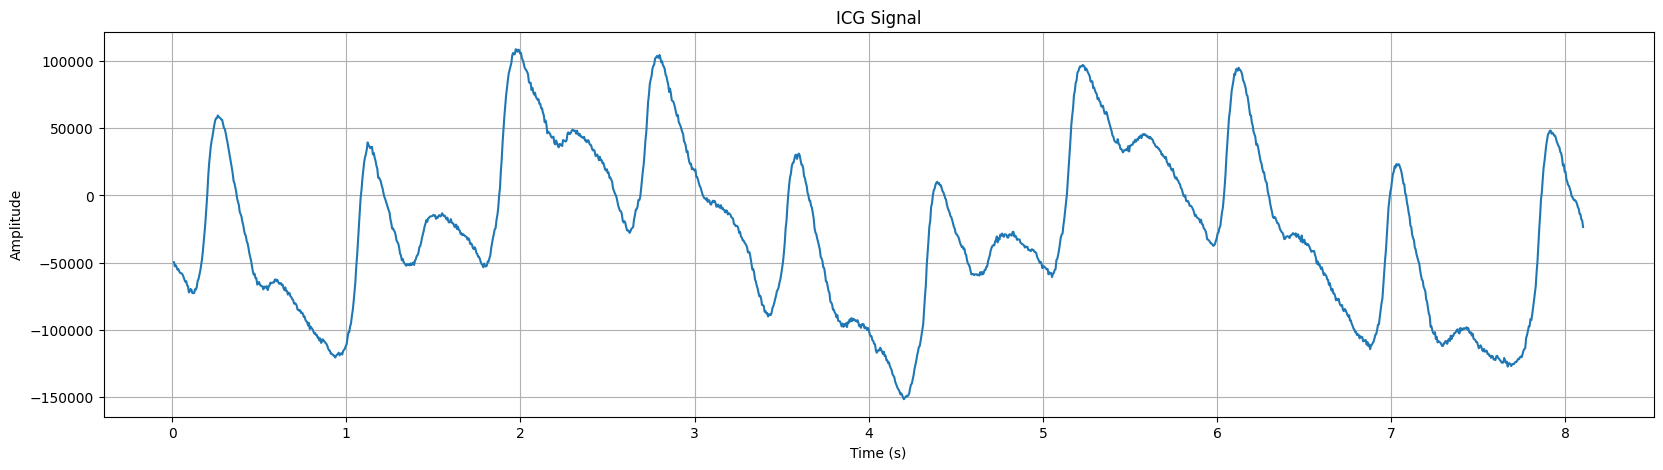

In [ ]:
icg = measures[1,1] #extract the ICG signal
icg_time = icg['time'][0,0].flatten()
icg_data = icg['data'][0,0].flatten()

plt.figure(figsize=(20, 5))
plt.plot(icg_time, icg_data)
plt.title('ICG Signal')
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.grid(True)
plt.show()

Band pass filtering

In [ ]:
dt = np.mean(np.diff(icg_time))      #time step, we calculate the average interval between consecutive time samples
fs = 1 / dt                          #sampling frequency
print(fs) #198.45387059502093

198.71124064372685


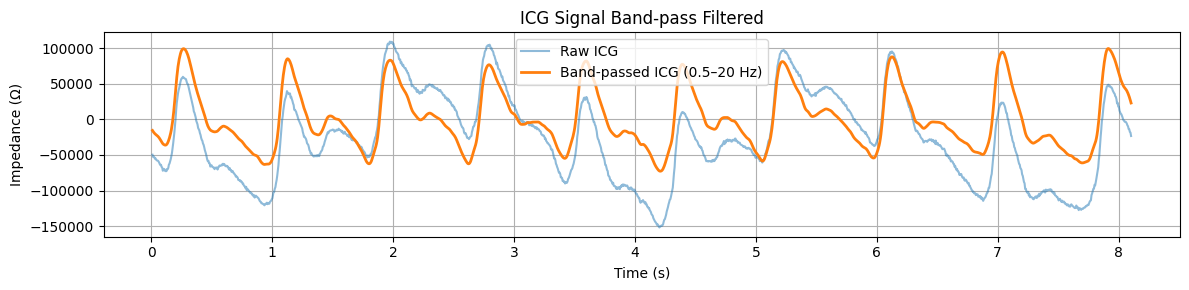

In [ ]:
def bandpass(signal, fs, lowcut, highcut, order=2):
    nyq = 0.5 * fs
    low = lowcut / nyq
    high = highcut / nyq
    b, a = butter(order, [low, high], btype='band')
    return filtfilt(b, a, signal)
icg_bandpassed = bandpass(icg_data, fs,0.5,20)

plt.figure(figsize=(12, 3))
plt.plot(icg_time, icg_data, label='Raw ICG', alpha=0.5)
plt.plot(icg_time, icg_bandpassed, label='Band-passed ICG (0.5–20 Hz)', linewidth=2)
plt.xlabel('Time (s)')
plt.ylabel('Impedance (Ω)')
plt.title('ICG Signal Band-pass Filtered')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


Baseline removal

The Savitzky-Golay filter is a smoothing filter based on local polynomial regression. Instead of simply averaging neighboring points (like a moving average does), SG fits a polynomial curve to a small window of the data, and replaces the center point with the value predicted by that polynomial.

We use SG to estimate the low-frequency trend (baseline), and then subtract it. Here, SG is not used to smooth the signal but to isolate the low-frequency component (like respiration or motion drift).

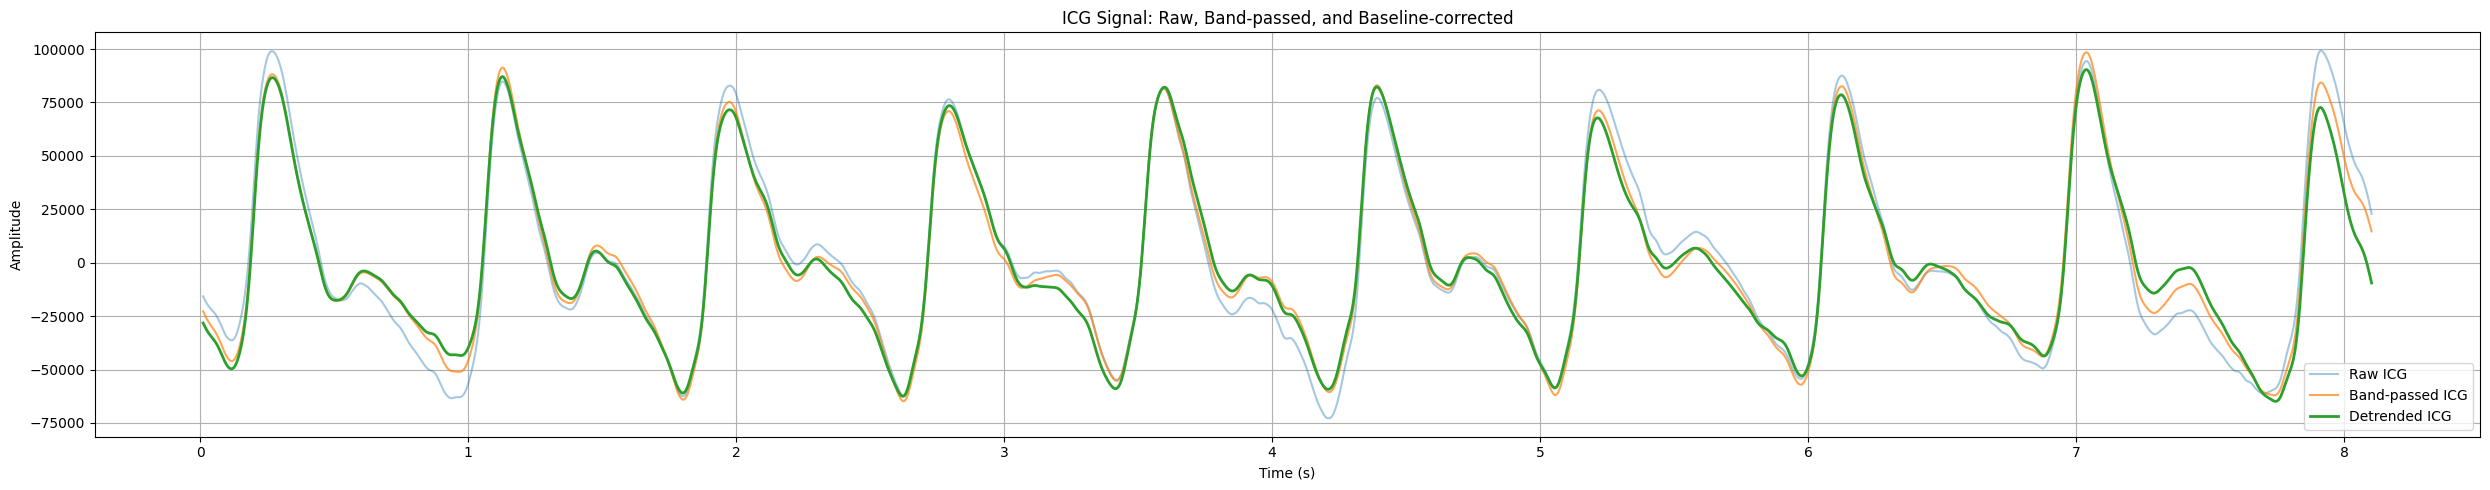

Text(0.5, 1.0, 'Preprocessed ICG Signal')

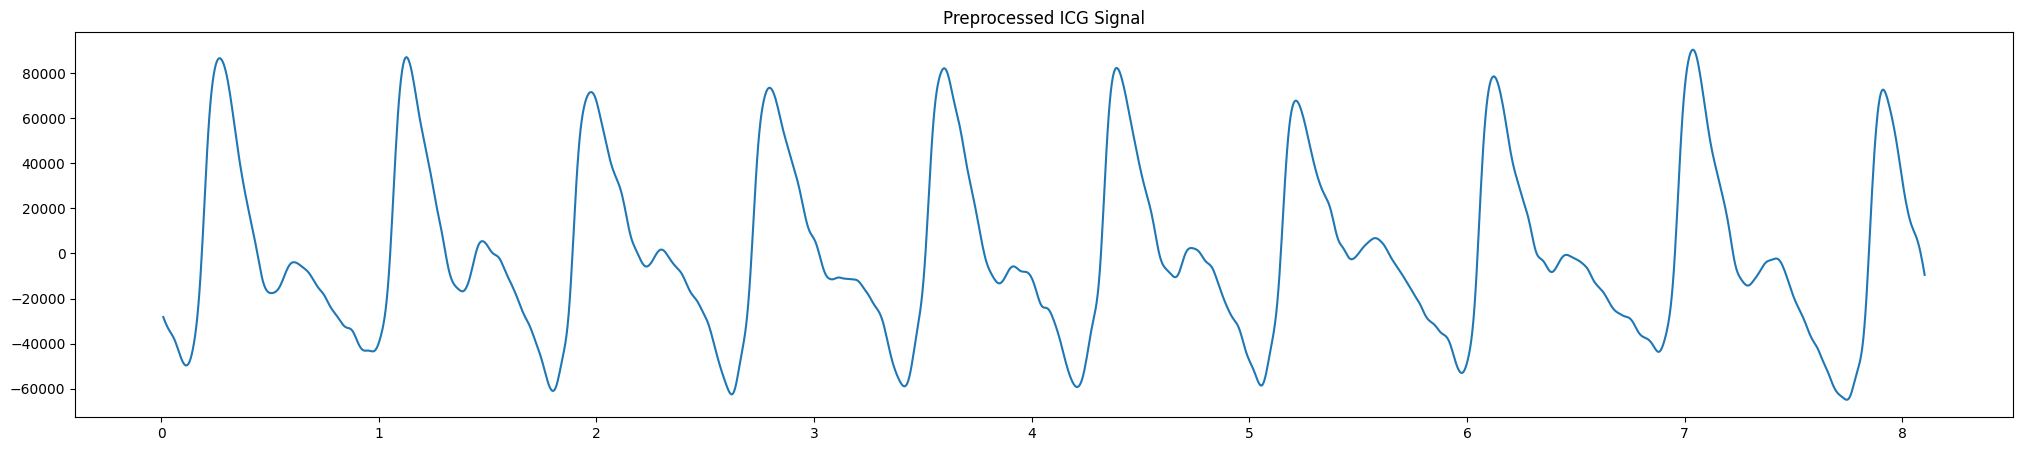

In [ ]:
def preprocess_icg_detrend(icg_data, icg_time, fs, lowcut=0.7, highcut=20.0, order=2, sg_window=301, sg_poly=2):
    # Bandpass filter
    nyq = 0.5 * fs
    low = lowcut / nyq
    high = highcut / nyq
    b, a = butter(order, [low, high], btype='band')
    icg_bandpassed = filtfilt(b, a, icg_data)

    # Baseline estimation using SG and subtraction
    baseline = savgol_filter(icg_bandpassed, window_length=sg_window, polyorder=sg_poly)
    icg_detrended = icg_bandpassed - baseline

    # Plot
    plt.figure(figsize=(25, 5))
    plt.plot(icg_time, icg_data, label='Raw ICG', alpha=0.4)
    plt.plot(icg_time, icg_bandpassed, label='Band-passed ICG', alpha=0.7)
    plt.plot(icg_time, icg_detrended, label='Detrended ICG', linewidth=2)
    plt.legend()
    plt.title("ICG Signal: Raw, Band-passed, and Baseline-corrected")
    plt.xlabel("Time (s)")
    plt.ylabel("Amplitude")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    return icg_detrended

icg_detrended = preprocess_icg_detrend(icg_bandpassed, icg_time, fs, lowcut=0.7, highcut=20.0, order=2, sg_window=301, sg_poly=2)
plt.figure(figsize=(25, 5))
plt.plot(icg_time, icg_detrended)
plt.title("Preprocessed ICG Signal")

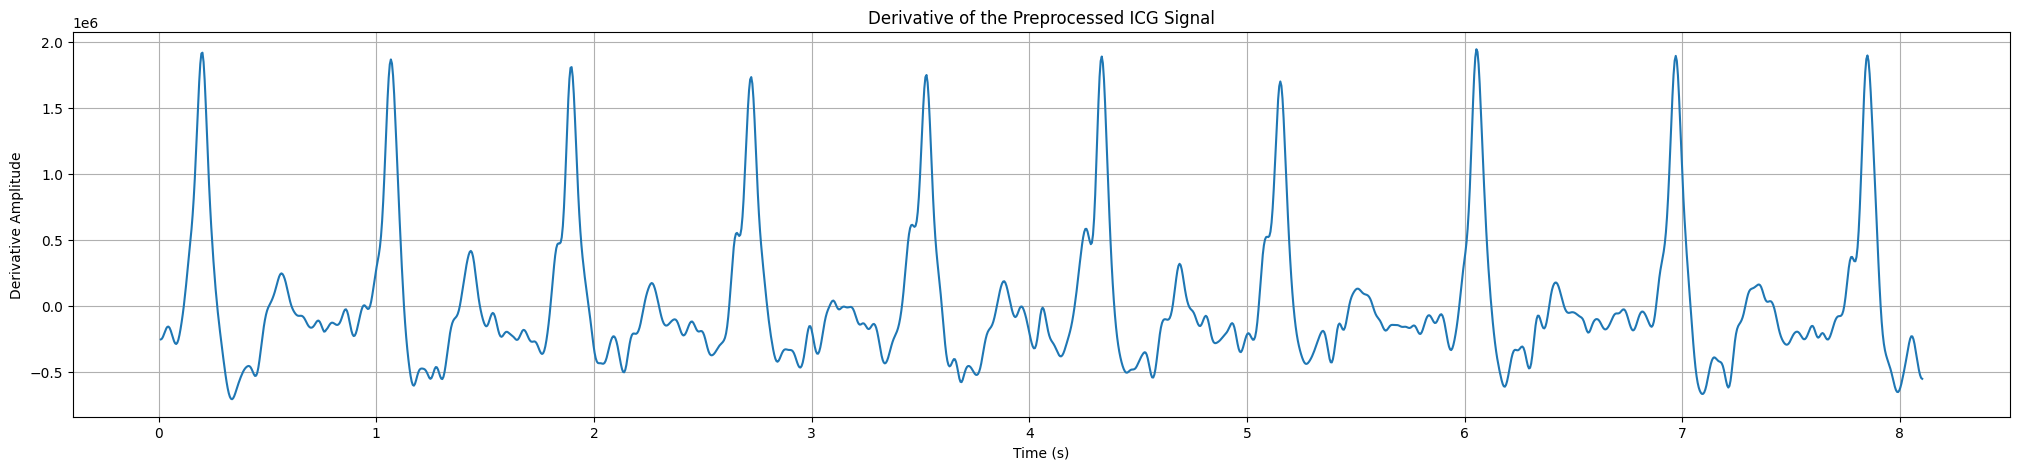

In [ ]:
# Calculate the derivative using central difference method
dt = np.mean(np.diff(icg_time))
dz_dt = np.gradient(icg_detrended, dt)

# Plot the derivative
plt.figure(figsize=(25, 5))
plt.plot(icg_time, dz_dt)
plt.title("Derivative of the Preprocessed ICG Signal")
plt.xlabel("Time (s)")
plt.ylabel("Derivative Amplitude")
plt.grid(True)
plt.show()


Conclusion: We apply band-pass filtering followed by Savitzky-Golay (SG) filtering to detrend the impedance signal. After obtaining the cleaned signal, we compute its derivative to enhance characteristic point detection.

##ECG Preprocessing

We have 4 ECG signals with different sampling frequencies.

Sampling Frequency ECG 1: 198.71 Hz
Sampling Frequency ECG 2: 43797.38 Hz
Sampling Frequency ECG 3: 136.00 Hz
Sampling Frequency ECG 4: 495.90 Hz


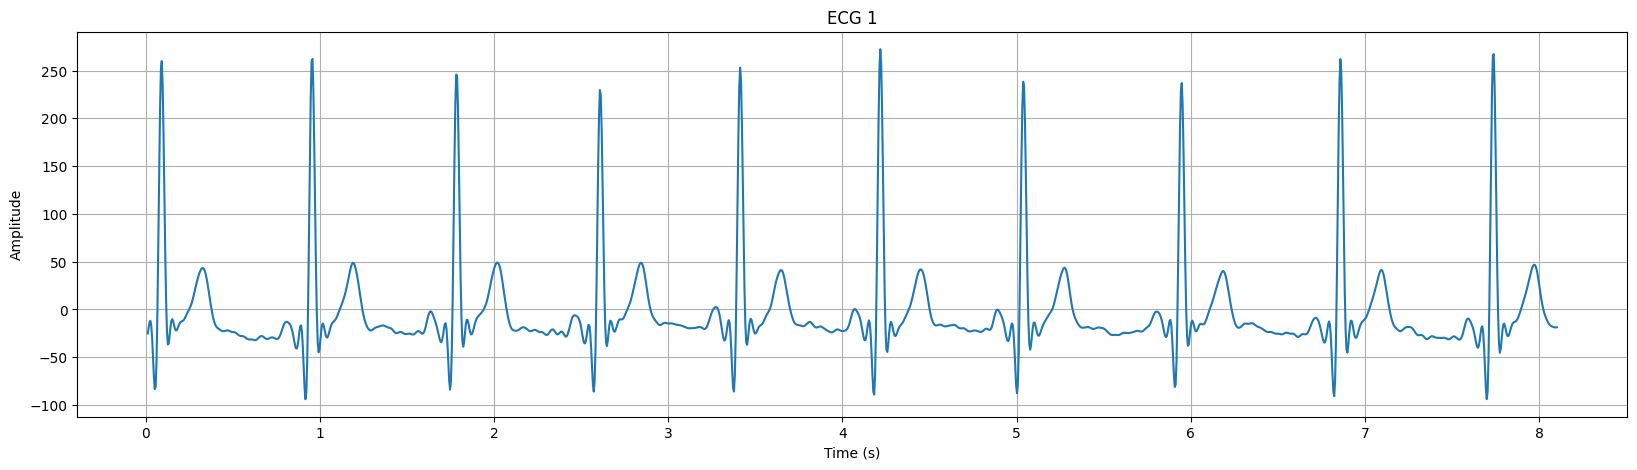

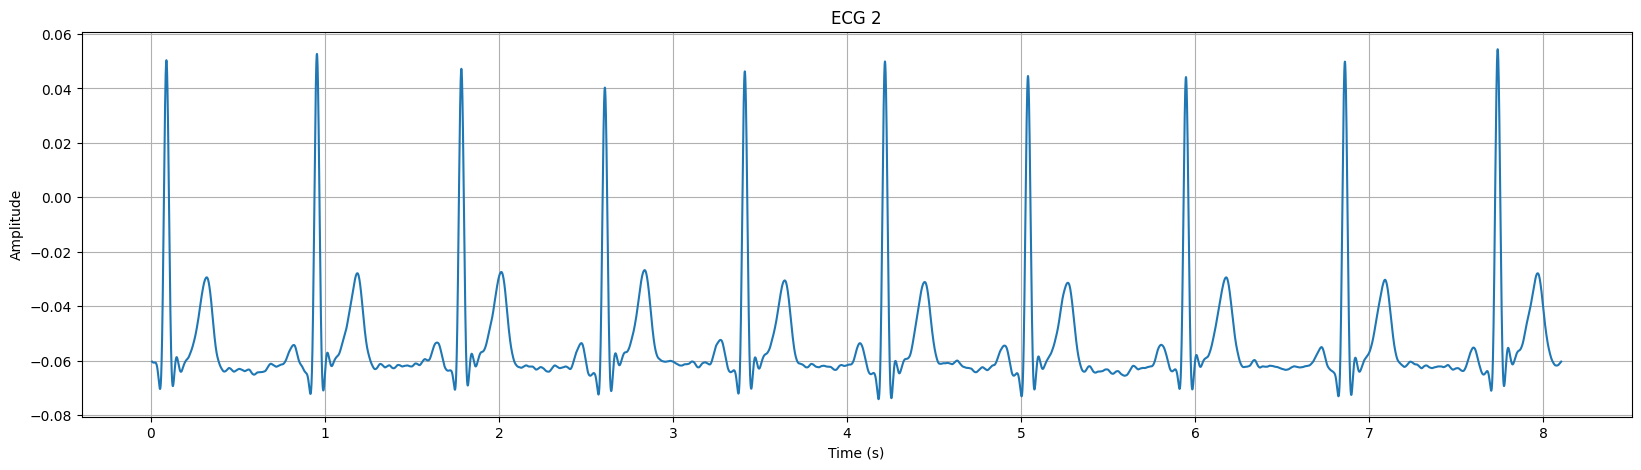

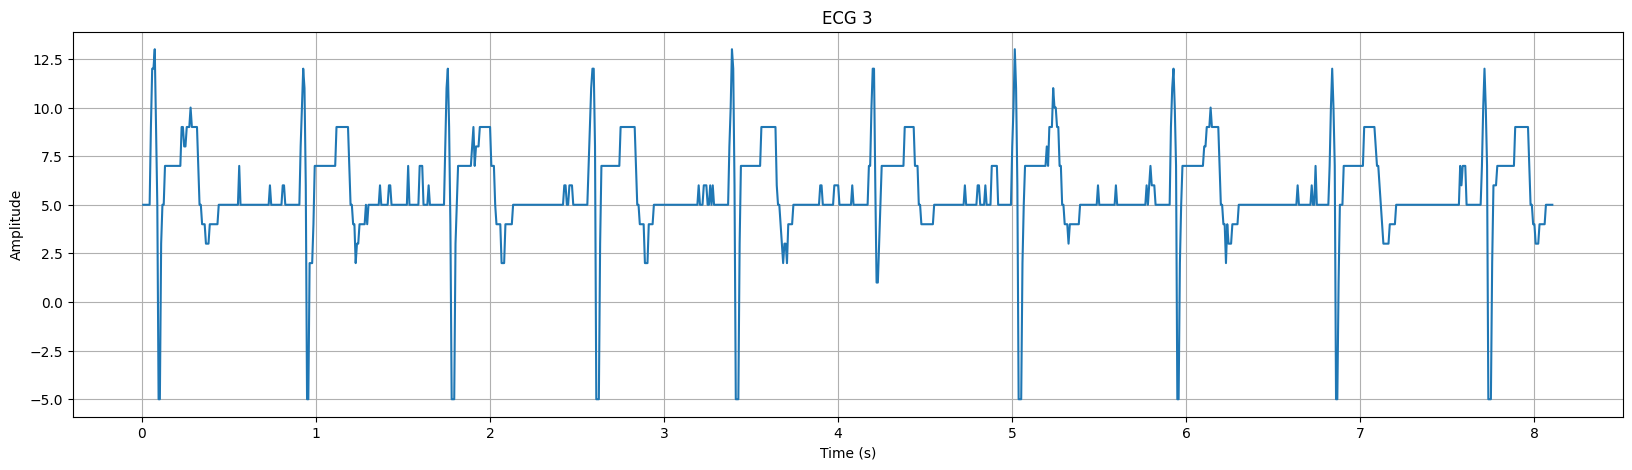

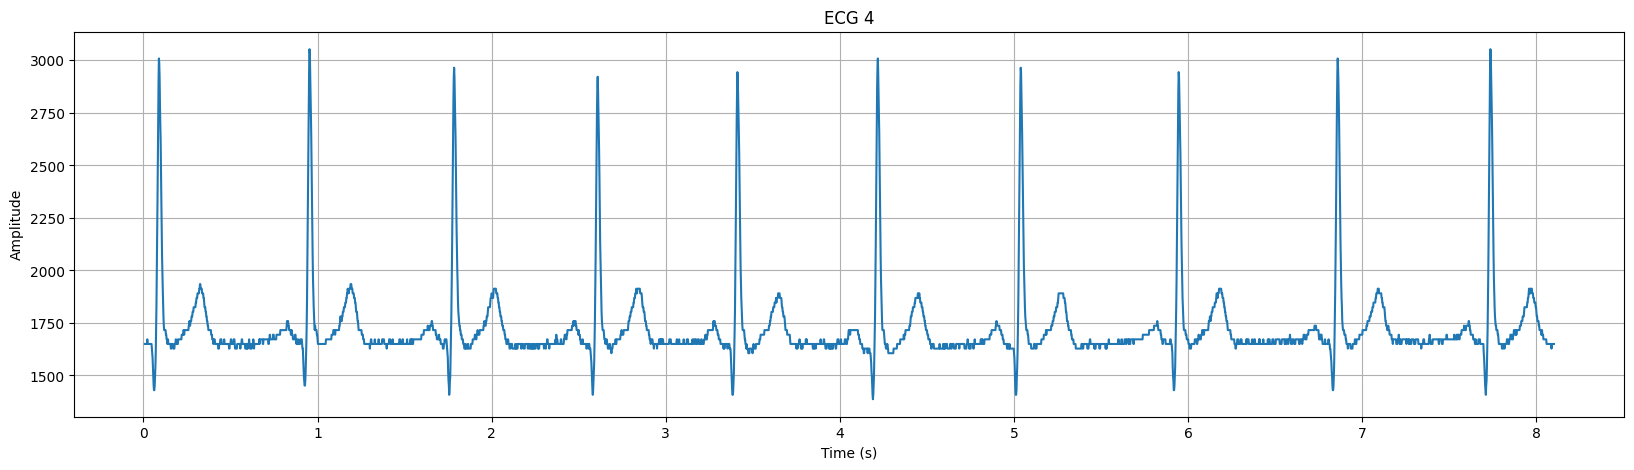

In [ ]:
ecg_1 = measures[0, 1]
ecg_2 = measures[0, 2]
ecg_3 = measures[0, 3]
ecg_4 = measures[0, 4]

ecg_1_time = ecg_1['time'][0, 0].flatten()
ecg_1_data = ecg_1['data'][0, 0].flatten()

ecg_2_time = ecg_2['time'][0, 0].flatten()
ecg_2_data = ecg_2['data'][0, 0].flatten()

ecg_3_time = ecg_3['time'][0, 0].flatten()
ecg_3_data = ecg_3['data'][0, 0].flatten()

ecg_4_time = ecg_4['time'][0, 0].flatten()
ecg_4_data = ecg_4['data'][0, 0].flatten()

# Plot ECG 1
plt.figure(figsize=(20, 5))
plt.plot(ecg_1_time, ecg_1_data)
plt.title('ECG 1')
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.grid(True)

# Plot ECG 2
plt.figure(figsize=(20, 5))
plt.plot(ecg_2_time, ecg_2_data)
plt.title('ECG 2')
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.grid(True)

# Plot ECG 3
plt.figure(figsize=(20, 5))
plt.plot(ecg_3_time, ecg_3_data)
plt.title('ECG 3')
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.grid(True)

# Plot ECG 4
plt.figure(figsize=(20, 5))
plt.plot(ecg_4_time, ecg_4_data)
plt.title('ECG 4')
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.grid(True)

def get_sampling_frequency(time_array):
    time_diffs = np.diff(time_array)
    avg_time_step = np.mean(time_diffs)
    fs = 1 / avg_time_step
    return fs

fs_1 = get_sampling_frequency(ecg_1_time)
fs_2 = get_sampling_frequency(ecg_2_time)
fs_3 = get_sampling_frequency(ecg_3_time)
fs_4 = get_sampling_frequency(ecg_4_time)

print(f"Sampling Frequency ECG 1: {fs_1:.2f} Hz")
print(f"Sampling Frequency ECG 2: {fs_2:.2f} Hz")
print(f"Sampling Frequency ECG 3: {fs_3:.2f} Hz")
print(f"Sampling Frequency ECG 4: {fs_4:.2f} Hz")

We observe that ECG channel 1 often exhibits baseline drift. To address this, we apply a band-pass filter. The recommended range by the American Heart Association is 0.05 Hz to 150 Hz. However, we encounter a limitation:

ValueError: Digital filter critical frequencies must be 0 < Wn < 1

This error occurs because the high cutoff frequency (150 Hz) exceeds the valid range relative to the Nyquist frequency (nyq = fs_3 / 2). The butter function requires the cutoff frequencies to be normalized between 0 and 1, where 1 corresponds to the Nyquist frequency.


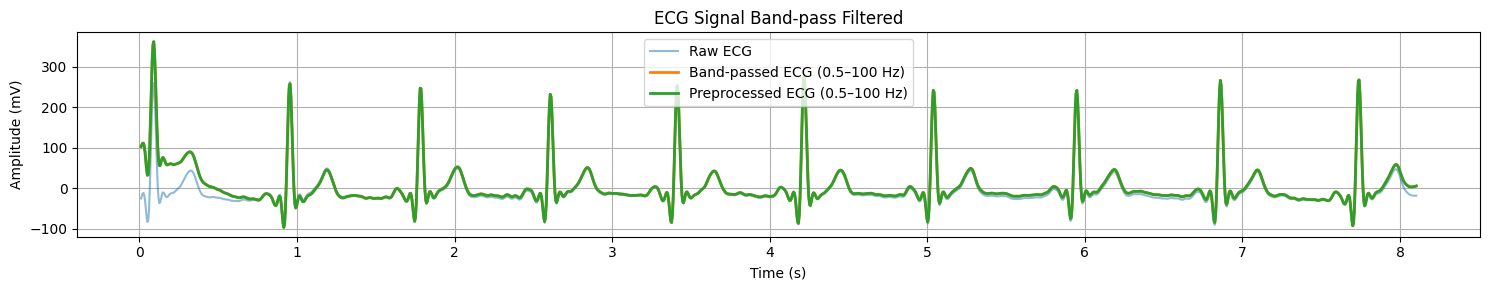

In [ ]:
from scipy.signal import iirnotch

def notch_filter(data, fs, freq=50, quality_factor=30):
    b, a = iirnotch(freq, quality_factor, fs)
    return filtfilt(b, a, data)

ecg_1_bandpassed = bandpass(ecg_1_data, fs_1, 0.5,45)
ecg_1_preprocessed = notch_filter(ecg_1_bandpassed, fs_1, freq=50, quality_factor=30)

plt.figure(figsize=(15, 3))
plt.plot(ecg_1_time, ecg_1_data, label='Raw ECG', alpha=0.5)
plt.plot(ecg_1_time, ecg_1_bandpassed, label='Band-passed ECG (0.5–100 Hz)', linewidth=2)
plt.plot(ecg_1_time, ecg_1_preprocessed, label='Preprocessed ECG (0.5–100 Hz)', linewidth=2)
plt.xlabel('Time (s)')
plt.ylabel('Amplitude (mV)')
plt.title('ECG Signal Band-pass Filtered')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

We observe that ecg_1_bandpassed and ecg_1_preprocessed are identical, indicating that the signal likely did not contain power line interference and therefore required no additional cleaning in that frequency range.

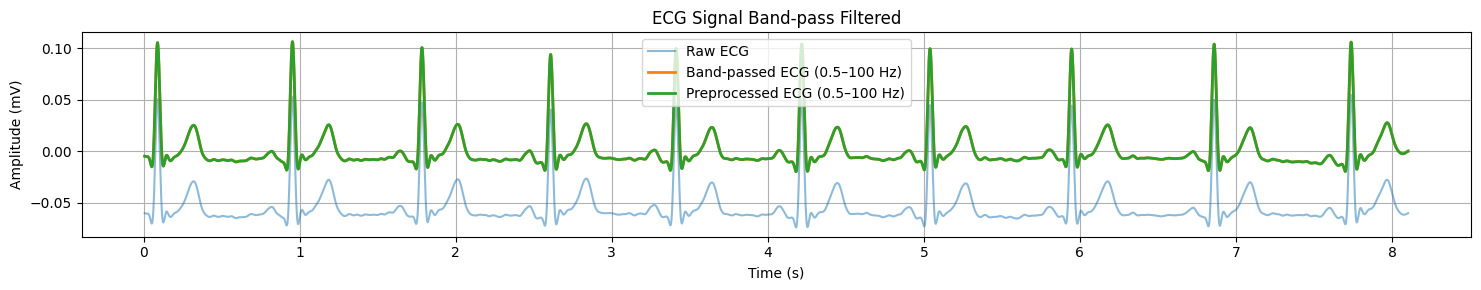

In [ ]:
ecg_2_bandpassed = bandpass(ecg_2_data, fs_2, 0.5,100)
ecg_2_preprocessed = notch_filter(ecg_2_bandpassed, fs_2, freq=50, quality_factor=30)

plt.figure(figsize=(15, 3))
plt.plot(ecg_2_time, ecg_2_data, label='Raw ECG', alpha=0.5)
plt.plot(ecg_2_time, ecg_2_bandpassed, label='Band-passed ECG (0.5–100 Hz)', linewidth=2)
plt.plot(ecg_2_time, ecg_2_preprocessed, label='Preprocessed ECG (0.5–100 Hz)', linewidth=2)
plt.xlabel('Time (s)')
plt.ylabel('Amplitude (mV)')
plt.title('ECG Signal Band-pass Filtered')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

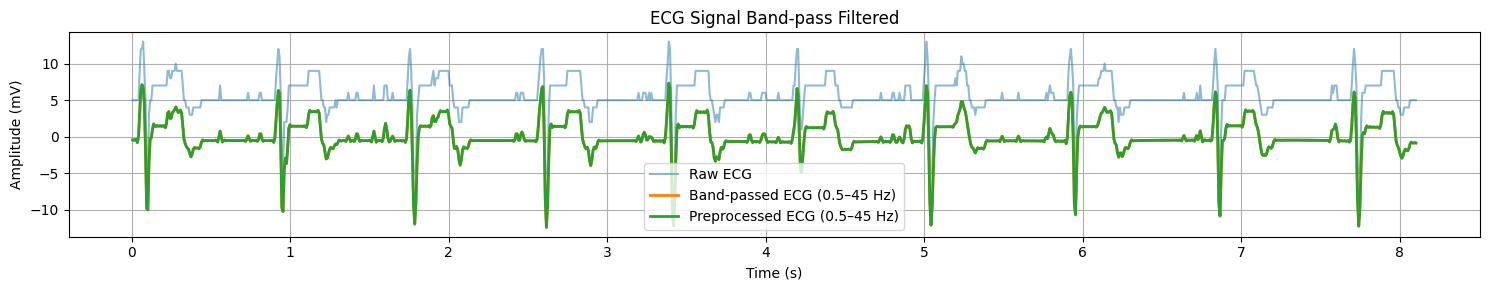

In [ ]:
ecg_3_bandpassed = bandpass(ecg_3_data, fs_3, 0.5, 45)
ecg_3_preprocessed = notch_filter(ecg_3_bandpassed, fs_3, freq=50, quality_factor=30)

plt.figure(figsize=(15, 3))
plt.plot(ecg_3_time, ecg_3_data, label='Raw ECG', alpha=0.5)
plt.plot(ecg_3_time, ecg_3_bandpassed, label='Band-passed ECG (0.5–45 Hz)', linewidth=2)
plt.plot(ecg_3_time, ecg_3_preprocessed, label='Preprocessed ECG (0.5–45 Hz)', linewidth=2)
plt.xlabel('Time (s)')
plt.ylabel('Amplitude (mV)')
plt.title('ECG Signal Band-pass Filtered')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


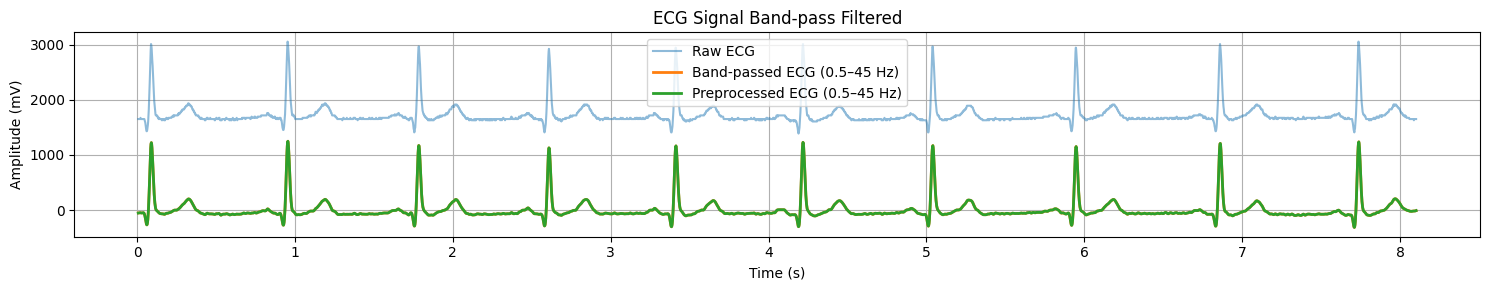

In [ ]:
ecg_4_bandpassed = bandpass(ecg_4_data, fs_4, 0.5, 45)
ecg_4_preprocessed = notch_filter(ecg_4_bandpassed, fs_4, freq=50, quality_factor=30)

plt.figure(figsize=(15, 3))
plt.plot(ecg_4_time, ecg_4_data, label='Raw ECG', alpha=0.5)
plt.plot(ecg_4_time, ecg_4_bandpassed, label='Band-passed ECG (0.5–45 Hz)', linewidth=2)
plt.plot(ecg_4_time, ecg_4_preprocessed, label='Preprocessed ECG (0.5–45 Hz)', linewidth=2)
plt.xlabel('Time (s)')
plt.ylabel('Amplitude (mV)')
plt.title('ECG Signal Band-pass Filtered')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


We normalize with Z score so we can plot it with ICG.

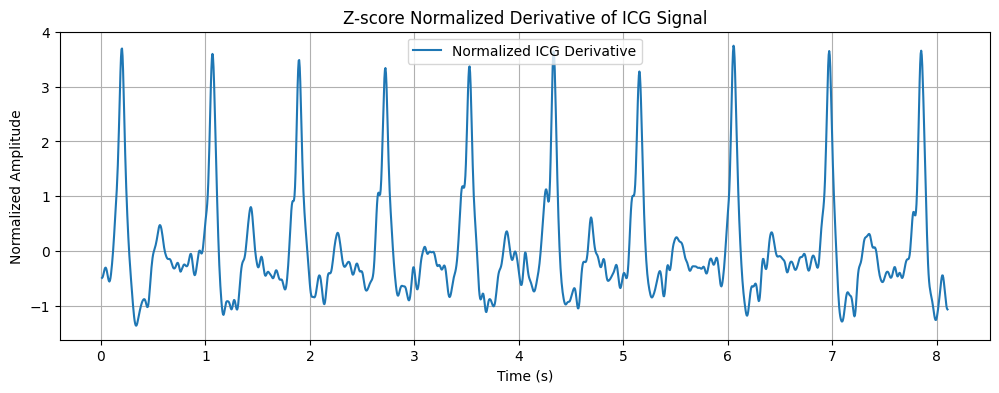

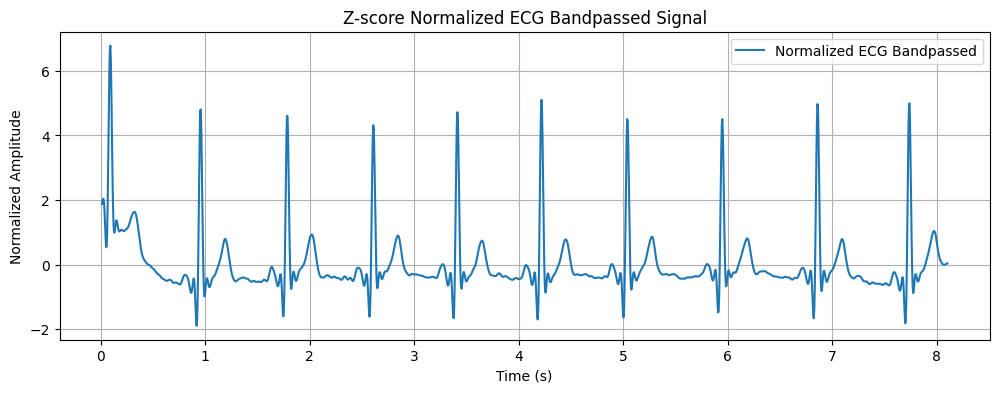

In [ ]:
scaler_icg = StandardScaler()
dz_dt_norm = scaler_icg.fit_transform(dz_dt.reshape(-1, 1))

scaler_ecg = StandardScaler()
ecg_1_bandpassed_normalized = scaler_ecg.fit_transform(ecg_1_bandpassed.reshape(-1, 1))

# Plot normalized ICG derivative
plt.figure(figsize=(12, 4))
plt.plot(icg_time, dz_dt_norm, label='Normalized ICG Derivative')
plt.xlabel('Time (s)')
plt.ylabel('Normalized Amplitude')
plt.title('Z-score Normalized Derivative of ICG Signal')
plt.grid(True)
plt.legend()
plt.show()

# Plot normalized ECG
plt.figure(figsize=(12, 4))
plt.plot(ecg_1_time, ecg_1_bandpassed_normalized, label='Normalized ECG Bandpassed')
plt.xlabel('Time (s)')
plt.ylabel('Normalized Amplitude')
plt.title('Z-score Normalized ECG Bandpassed Signal')
plt.grid(True)
plt.legend()
plt.show()


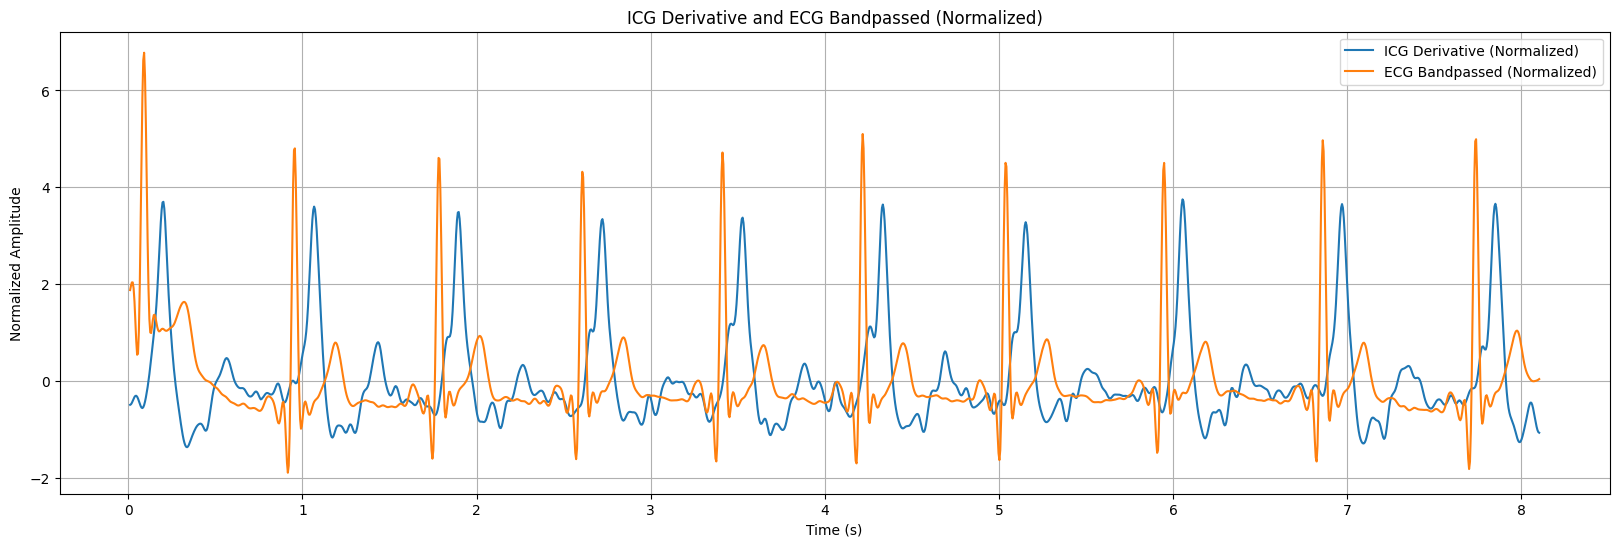

In [ ]:
plt.figure(figsize=(20, 6))
plt.plot(icg_time, dz_dt_norm, label='ICG Derivative (Normalized)')
plt.plot(ecg_1_time, ecg_1_bandpassed_normalized, label='ECG Bandpassed (Normalized)')
plt.xlabel('Time (s)')
plt.ylabel('Normalized Amplitude')
plt.title('ICG Derivative and ECG Bandpassed (Normalized)')
plt.legend()
plt.grid(True)
plt.show()


#ECG R peaks

[0.09095151 0.95652912 1.7818473  2.60716548 3.41235395 4.21754242
 5.03782818 5.94869764 6.85956709 7.74024198]


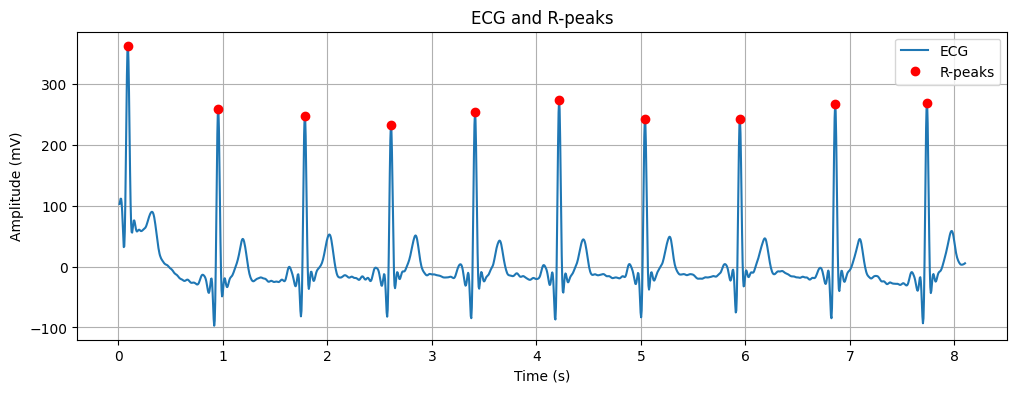

In [ ]:
rpeaks = measures[2,1]
rpeaks_time = rpeaks['time'][0,0].flatten()
rpeaks_values = rpeaks['data'][0,0].flatten()

rpeaks_times = np.array(rpeaks_values) # numpy array
print(rpeaks_times)

# find the closest points to the time second
rpeaks_index = np.array([np.argmin(np.abs(ecg_1_time - t)) for t in rpeaks_times])

plt.figure(figsize=(12, 4))
plt.plot(ecg_1_time, ecg_1_preprocessed, label='ECG')
plt.plot(ecg_1_time[rpeaks_index], ecg_1_preprocessed[rpeaks_index], 'ro', label='R-peaks') #put the r peaks in red points
plt.xlabel('Time (s)')
plt.ylabel('Amplitude (mV)')
plt.title('ECG and R-peaks')
plt.legend()
plt.grid(True)
plt.show()


Normalize ECG and ICG (MinMax)

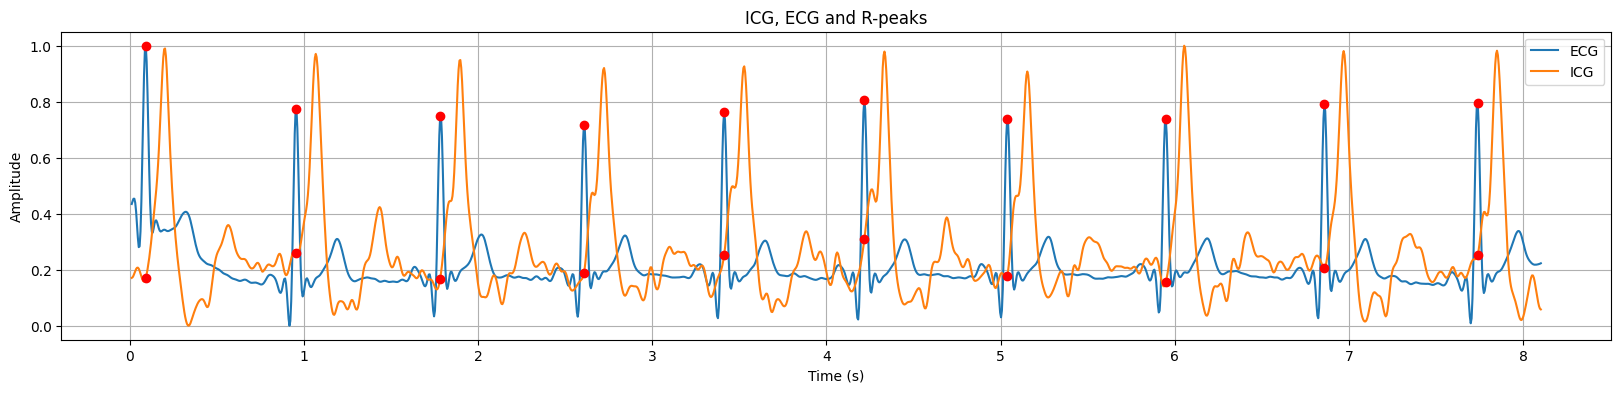

In [ ]:
def normalize(signal):
    return (signal - np.min(signal)) / (np.max(signal) - np.min(signal))

ecg_norm = normalize(ecg_1_preprocessed)
icg_norm = normalize(dz_dt)

plt.figure(figsize=(20, 4))
plt.plot(ecg_1_time, ecg_norm, label='ECG')
plt.plot(icg_time, icg_norm, label='ICG')
plt.plot(ecg_1_time[rpeaks_index], ecg_norm[rpeaks_index], 'ro')
plt.plot(icg_time[rpeaks_index], icg_norm[rpeaks_index],'ro')
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.title('ICG, ECG and R-peaks')
plt.legend()
plt.grid(True)
plt.show()


# Echo

[[array([[7.35294118e-03],
         [1.47058824e-02],
         [2.20588235e-02],
         ...,
         [8.08823529e+00],
         [8.09558824e+00],
         [8.10294118e+00]])]]
(274, 1102)


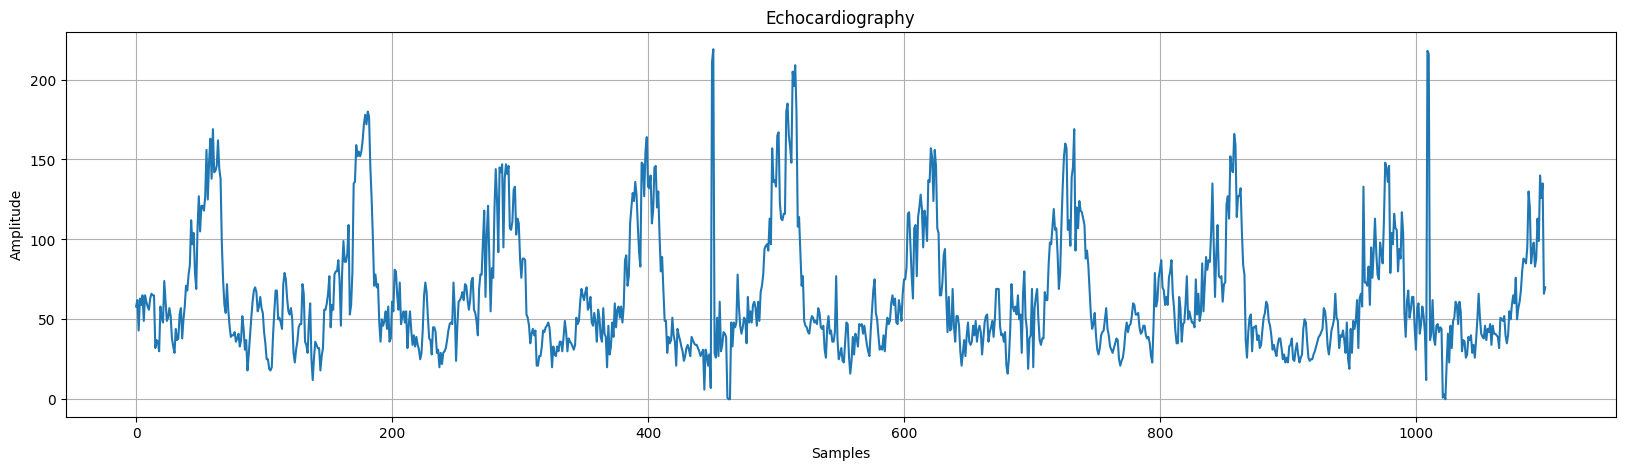

[7.35294118e-03 1.47058824e-02 2.20588235e-02 ... 8.08823529e+00
 8.09558824e+00 8.10294118e+00]
Sampling frequency: 136.00 Hz


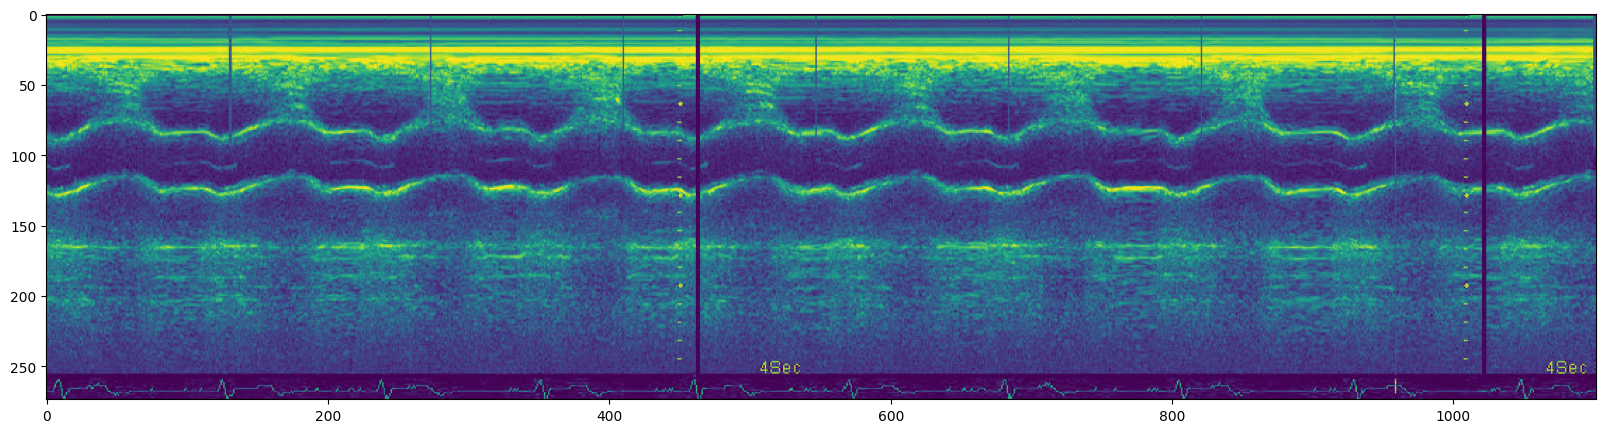

In [ ]:
echo = measures[1,3]
echo_time = echo['time']
echo_data = echo['data']
echo_value = echo_data[0, 0]

print(echo_time)

echo_value_1 = echo_value[:, :, 0]  #all time frames, channel 0, covering all depth points
print(echo_value_1.shape)
#it means we extract all lines

echo_one_line = echo_value[65, :, 0] #we see in the echo picture that not all depths are information so we choose one that helps finding AVO and AVC
plt.figure(figsize=(20, 5))
plt.plot(echo_one_line)
plt.title('Echocardiography')
plt.xlabel('Samples')
plt.ylabel('Amplitude')
plt.grid(True)
plt.show()

# we look at the echo image
plt.figure(figsize=(20, 8))
plt.imshow(echo_value_1)

# Unwrap the echo_time to get the 2D array inside the list
echo_time_array = echo_time[0]  # unwrap the list
echo_time_flat = echo_time_array[0]
echo_really_flat = echo_time_flat.flatten()  # flatten to 1D
print(echo_really_flat)

# Calculate the time step
dt = echo_really_flat[1] - echo_really_flat[0]
fs_echo = 1 / dt

print(f"Sampling frequency: {fs_echo:.2f} Hz")


274
[116 103 102 ...  35  50  45]


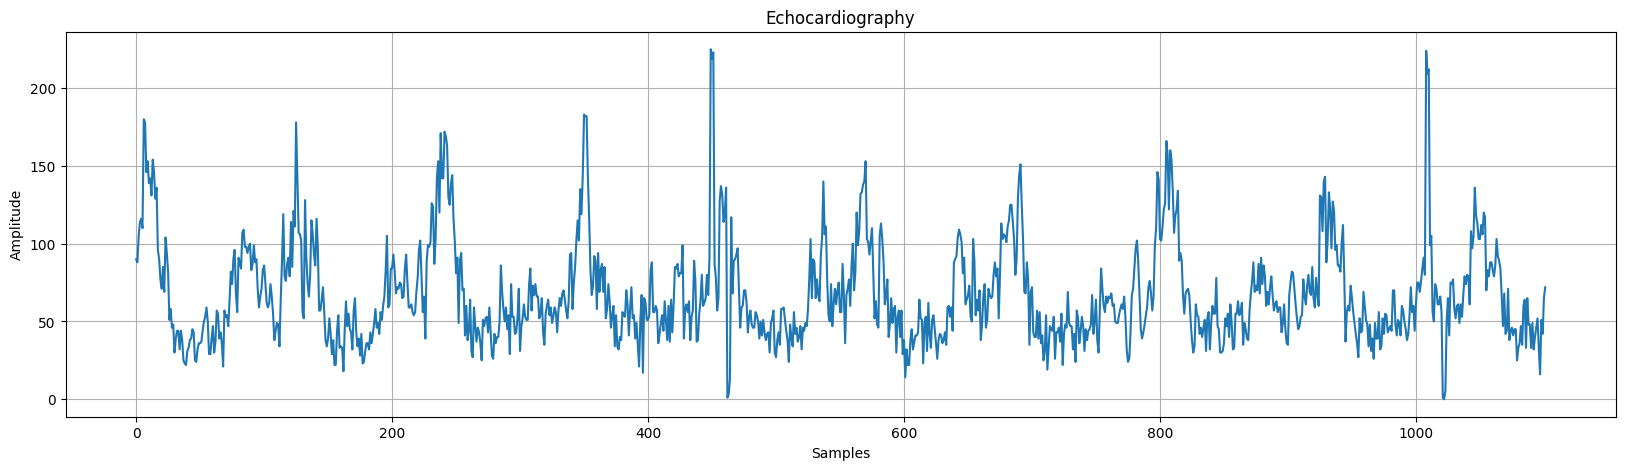

In [ ]:
depth_count = echo_value.shape[0]

all_echo_lines = []

for i in range(depth_count):
    echo_value_i = echo_data[0, 0][i, :, 0]  # or echo_value[i, :, 0] if echo_value is still valid
    all_echo_lines.append(echo_value_i)

print(len(all_echo_lines)) #274 lines
print(all_echo_lines[131])

plt.figure(figsize=(20, 5))
plt.plot(all_echo_lines[90])
plt.title('Echocardiography')
plt.xlabel('Samples')
plt.ylabel('Amplitude')
plt.grid(True)
plt.show()

# AVO and AVC in ECHO

In this section we plot AVO and AVC on the Echo signal to see if they match the opening and closure of the valves.

1102
1609
     Correlation (r)       p-value
0          -0.046114  6.441386e-02
1          -0.070074  4.922117e-03
2           0.040061  1.082023e-01
3           0.032540  1.920328e-01
4           0.008381  7.369248e-01
..               ...           ...
268        -0.259514  3.555879e-26
269        -0.200442  4.800296e-16
270        -0.124014  6.040753e-07
271        -0.086517  5.123338e-04
272        -0.070135  4.884688e-03

[273 rows x 2 columns]
Maximum r: 0.5386332903551379 at index 122 with p-value: 9.798318543062952e-122


<ipython-input-22-20c6107a4c90>:69: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  plt.axvline(x=int(time_point * fs_icg), color='r', linestyle='--', label='AVO')
<ipython-input-22-20c6107a4c90>:71: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  plt.axvline(x=int(time_point * fs_icg), color='b', linestyle='--', label='AVC')
<ipython-input-22-20c6107a4c90>:86: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  plt.axvline(x=int(time_point * fs_icg), color='r', linestyle='-

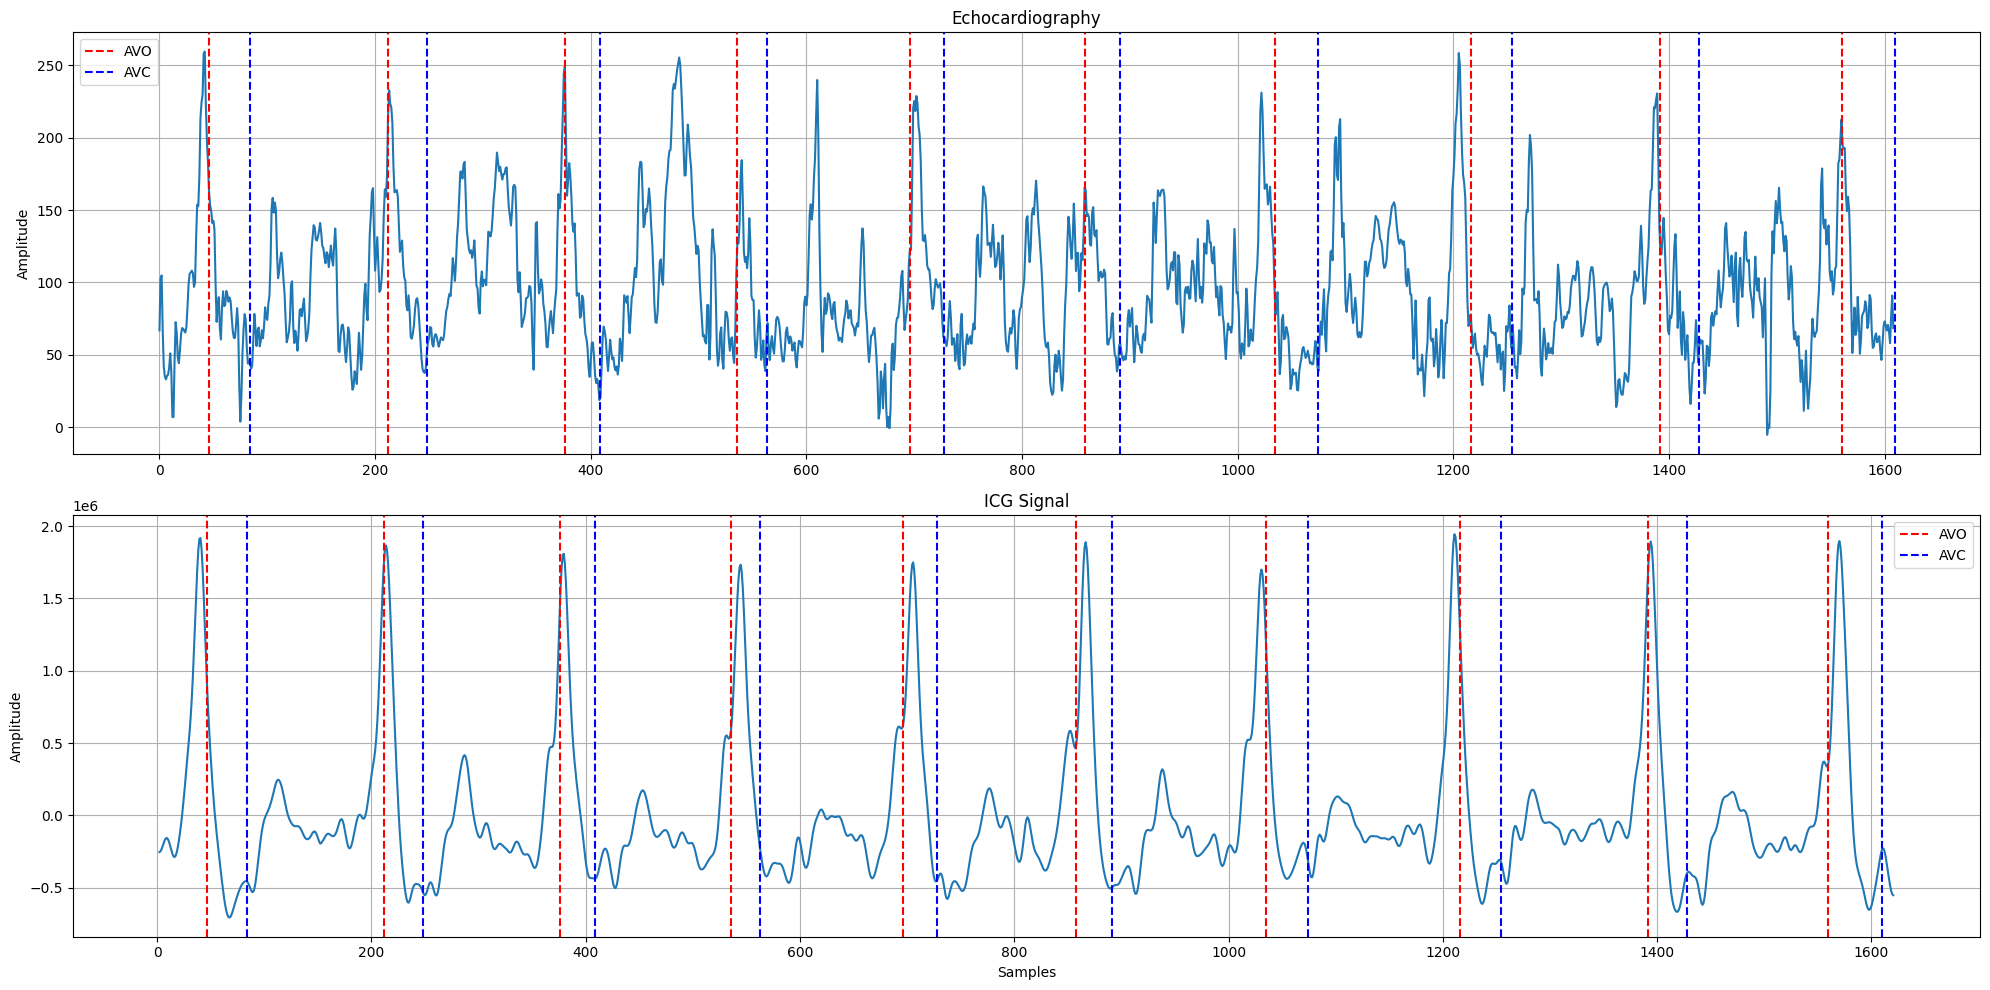

In [ ]:
from scipy.stats import pearsonr
from scipy.signal import resample

#obtain the avo info
avo_icg_all = measures[3,1]
avo_icg = avo_icg_all[0,0]
# avo_stc = measures[3,2] # avo_echo = measures[3,3] # avo_ppg = measures[3,4] #only the first one had more than 1 point
#print(avo_icg['data'])

#avc info
avc_icg_all = measures[5,1]
avc_icg = avc_icg_all[0,0]

echo = measures[1,3]
echo_time = echo['time']
echo_data = echo['data']
echo_value = echo_data[0, 0]

# we obtain all the lines in echo
echo_all_lines = []
for i in range(0,273): #we know the depth is 273
    echo_line = echo_value[i, :, 0]
    echo_all_lines.append(echo_line)

echo_all_lines = np.array(echo_all_lines)

#we see that the length of echo and icg don't match because they have different fs
print(len(echo_all_lines[35]))
print(len(dz_dt))

fs_echo = 136
fs_icg = 200

r_echo = []
p_echo = []
all_echo_resampled = []

for j in range(len(echo_all_lines)):
    echo_resampled = resample(echo_all_lines[j], len(dz_dt)) #we resample the echo signal to the icg length
    r, p = pearsonr(dz_dt, echo_resampled)
    r_echo.append(r)
    p_echo.append(p)
    all_echo_resampled.append(echo_resampled)

df = pd.DataFrame({
    'Correlation (r)': r_echo,
    'p-value': p_echo
})

print(df)

# we want to see the maximum correlation with the icg to select the most relevant line
max_r = max(r_echo)
max_index = r_echo.index(max_r)
corresponding_p = p_echo[max_index]

print(f"Maximum r: {max_r} at index {max_index} with p-value: {corresponding_p}")
# for 59146237/59146237_s0000002.mat --> Maximum r: 0.44308128368744776 at index 65 with p-value: 2.427494472173909e-78
# if we check the signal at 65 we see that it is the line with the most info (intuitively)
plt.figure(figsize=(20, 10))

plt.subplot(2, 1, 1)
plt.plot(all_echo_resampled[max_index])
plt.title('Echocardiography')
plt.ylabel('Amplitude')
plt.grid(True)

for time_point in avo_icg['data']:
    plt.axvline(x=int(time_point * fs_icg), color='r', linestyle='--', label='AVO')
for time_point in avc_icg['data']:
    plt.axvline(x=int(time_point * fs_icg), color='b', linestyle='--', label='AVC')

#  legend without duplicates
handles, labels = plt.gca().get_legend_handles_labels()
by_label = dict(zip(labels, handles))
plt.legend(by_label.values(), by_label.keys())

plt.subplot(2, 1, 2)
plt.plot(icg_time * fs_icg, dz_dt)
plt.title('ICG Signal')
plt.xlabel('Samples')
plt.ylabel('Amplitude')
plt.grid(True)

for time_point in avo_icg['data']:
    plt.axvline(x=int(time_point * fs_icg), color='r', linestyle='--', label='AVO')
for time_point in avc_icg['data']:
    plt.axvline(x=int(time_point * fs_icg), color='b', linestyle='--', label='AVC')

#  legend without duplicates
handles, labels = plt.gca().get_legend_handles_labels()
by_label = dict(zip(labels, handles))
plt.legend(by_label.values(), by_label.keys())

plt.tight_layout()
plt.show()

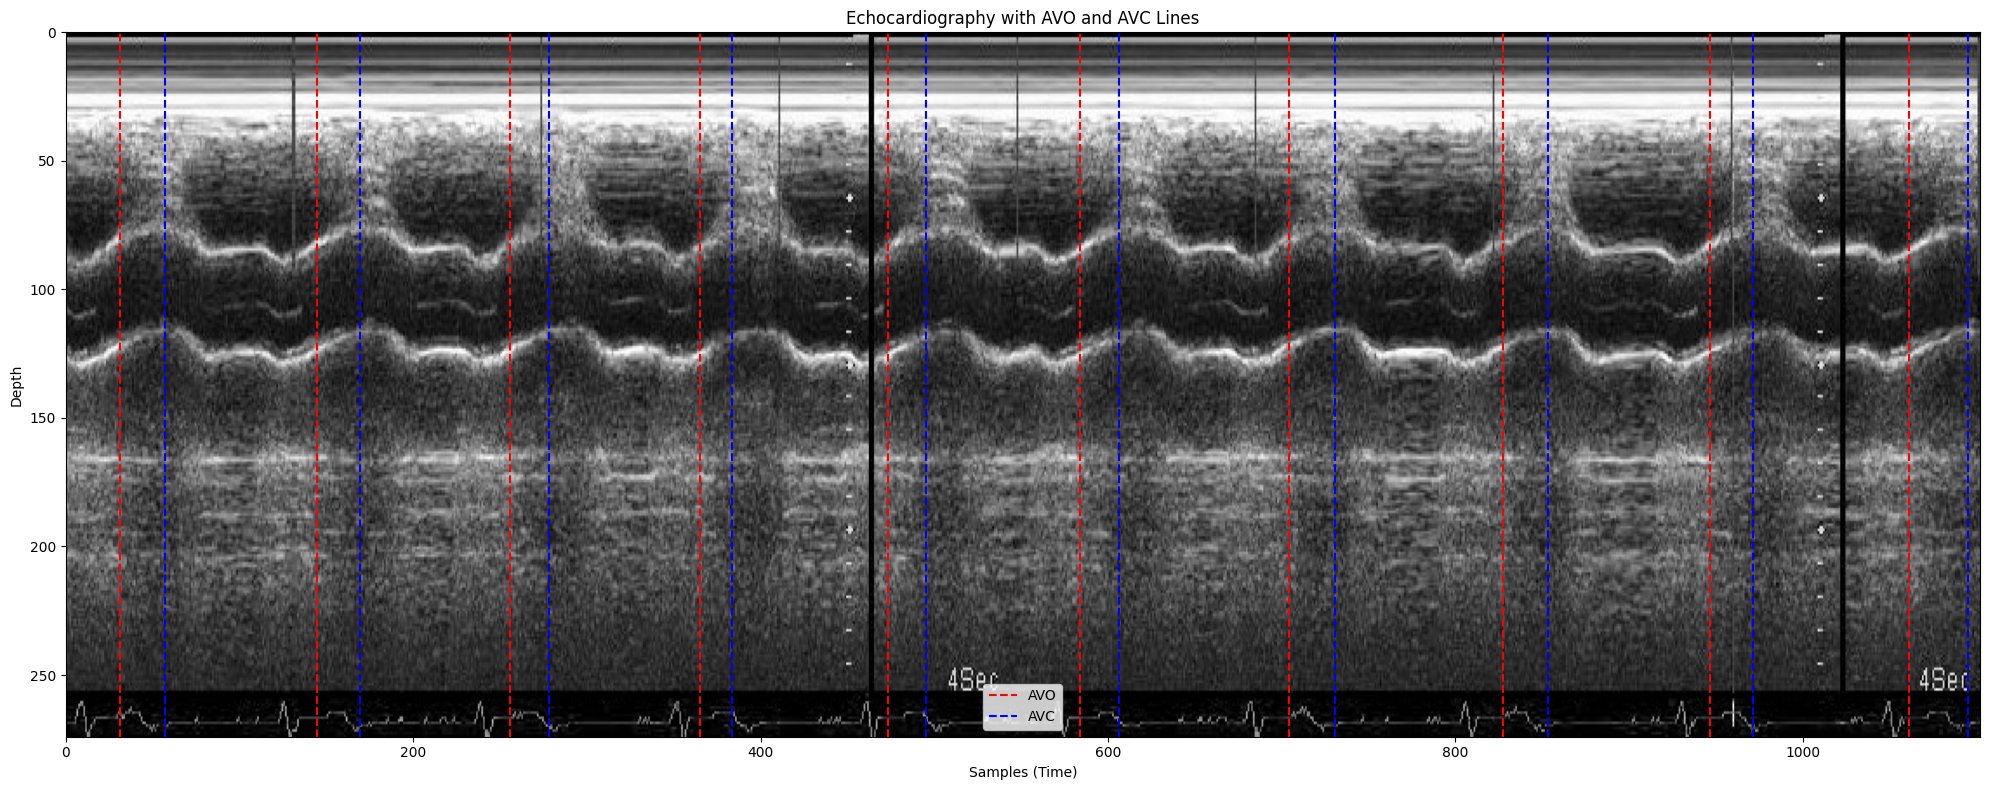

136


In [ ]:
# Plot echocardiography image
plt.figure(figsize=(20, 8))
plt.imshow(echo_value_1, aspect='auto', cmap='gray', extent=[0, echo_value_1.shape[1], echo_value_1.shape[0], 0])
plt.title("Echocardiography with AVO and AVC Lines")
plt.xlabel("Samples (Time)")
plt.ylabel("Depth")

# Draw AVO and AVC lines
for time_point in avo_icg['data']:
    x = time_point * fs_echo * (echo_value_1.shape[1] / len(echo_really_flat))  # Map time to column
    plt.axvline(x=x, color='r', linestyle='--', label='AVO')

for time_point in avc_icg['data']:
    x = time_point * fs_echo * (echo_value_1.shape[1] / len(echo_really_flat))
    plt.axvline(x=x, color='b', linestyle='--', label='AVC')

# Remove duplicate labels
handles, labels = plt.gca().get_legend_handles_labels()
by_label = dict(zip(labels, handles))
plt.legend(by_label.values(), by_label.keys())

plt.grid(False)
plt.tight_layout()
plt.show()

print(fs_echo)


#PCG


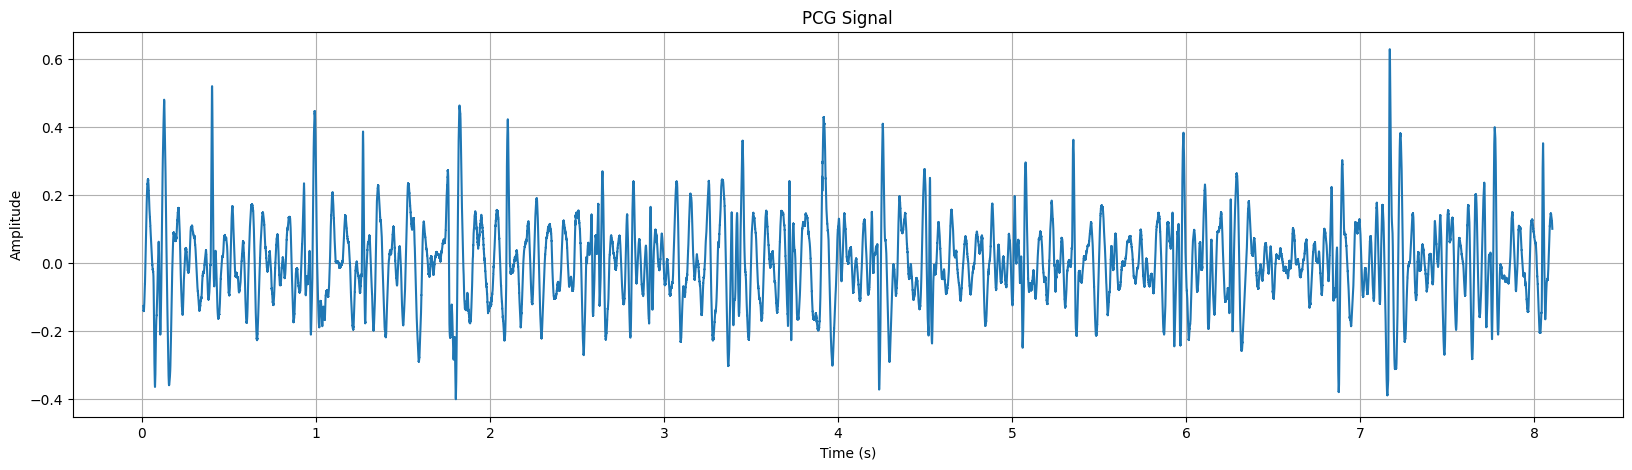

In [ ]:
import matplotlib.pyplot as plt
pcg = measures[1, 2]  # Extract PCG data
pcg_time = pcg['time'][0, 0].flatten()
pcg_data = pcg['data'][0, 0].flatten()

plt.figure(figsize=(20, 5))
plt.plot(pcg_time, pcg_data)
plt.title('PCG Signal')
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.grid(True)
plt.show()


In [ ]:
from scipy.signal import butter, filtfilt

def bandpass_filter(signal, fs, lowcut=20, highcut=100, order=3):
    nyquist = 0.5 * fs
    low = lowcut / nyquist
    high = highcut / nyquist
    b, a = butter(order, [low, high], btype='band')
    return filtfilt(b, a, signal)


In [ ]:
fs = 44100 #from metadata
pcg_filtered = bandpass_filter(pcg_data, fs)

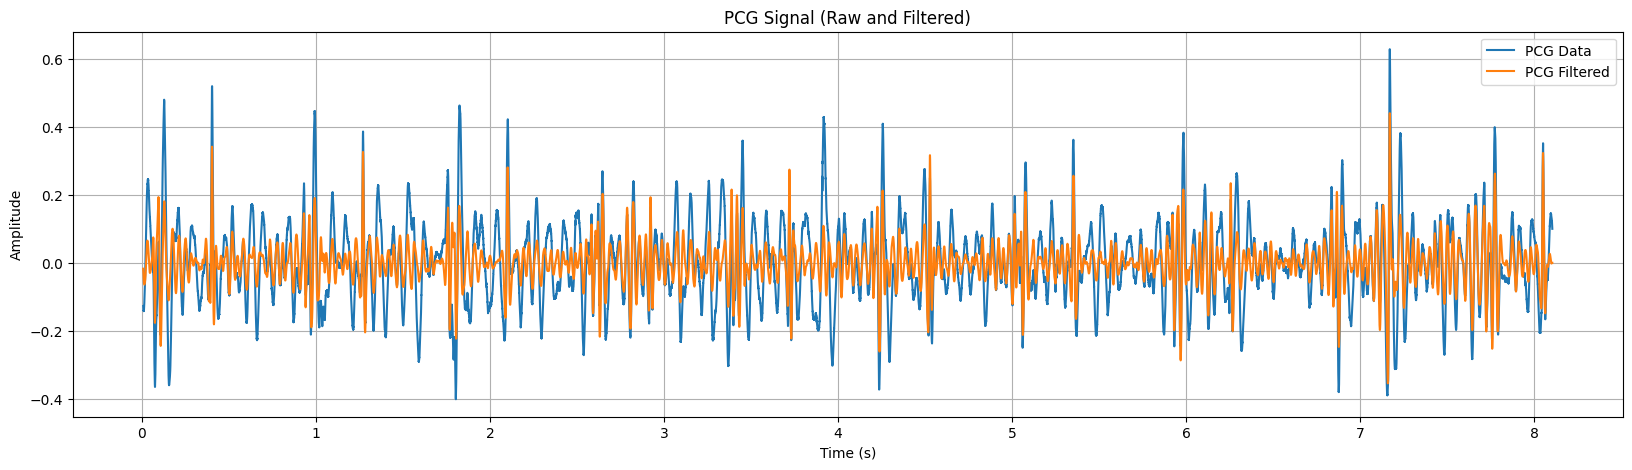

In [ ]:
# plot pcg_data and pcg_filtered

import matplotlib.pyplot as plt
plt.figure(figsize=(20, 5))
plt.plot(pcg_time, pcg_data, label='PCG Data')
plt.plot(pcg_time, pcg_filtered, label='PCG Filtered')
plt.title('PCG Signal (Raw and Filtered)')
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.legend()
plt.grid(True)
plt.show()


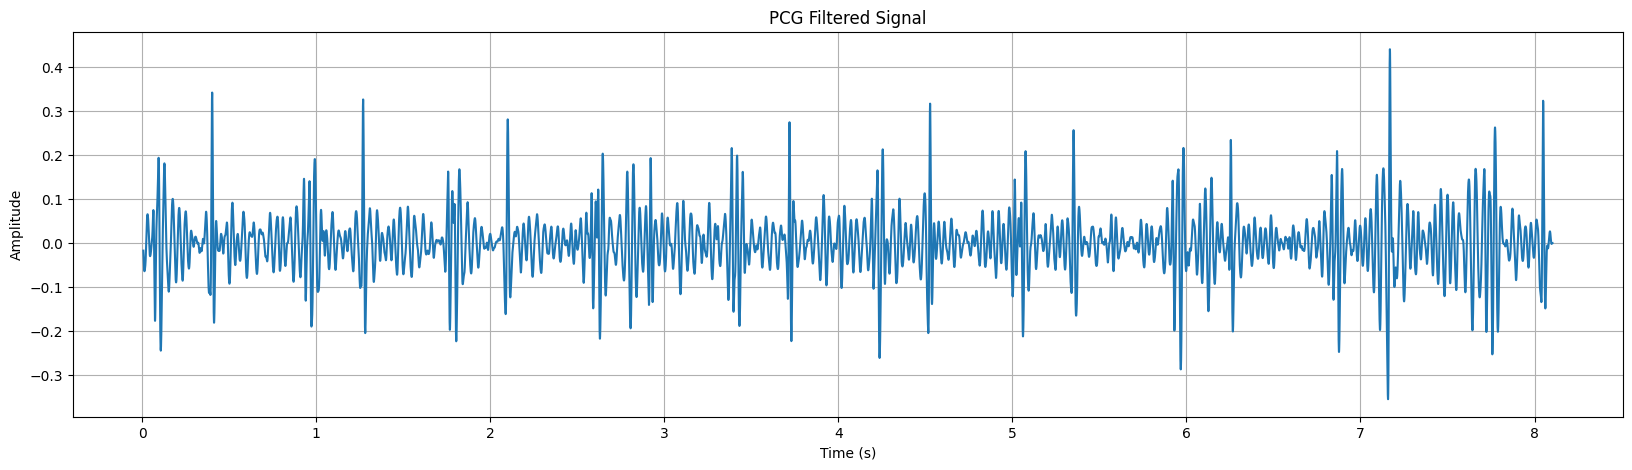

In [ ]:
plt.figure(figsize=(20, 5))
plt.plot(pcg_time, pcg_filtered)
plt.title('PCG Filtered Signal')
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.grid(True)
plt.show()


## We compute the envelope of the PCG
Heart sounds (S1, S2) in the PCG are short, high-amplitude events embedded in a noisy, oscillatory waveform. The raw PCG can be difficult to interpret and align with mechanical cardiac events like aortic valve opening (AVO) and closure (AVC) -> Computing the envelope of the PCG emphasizes the amplitude changes over time and suppresses high-frequency fluctuations --> Commonly used in heart sound segmentation

In [ ]:
import numpy as np

# Use squared signal + moving average
window_size = int(0.05 * fs)  # 50 ms window
envelope = np.convolve(pcg_filtered**2, np.ones(window_size)/window_size, mode='same') #squared so it's gonna be positive


In [ ]:
from scipy.signal import find_peaks

peaks, _ = find_peaks(envelope, distance=int(0.25 * fs), height=np.percentile(envelope, 75))

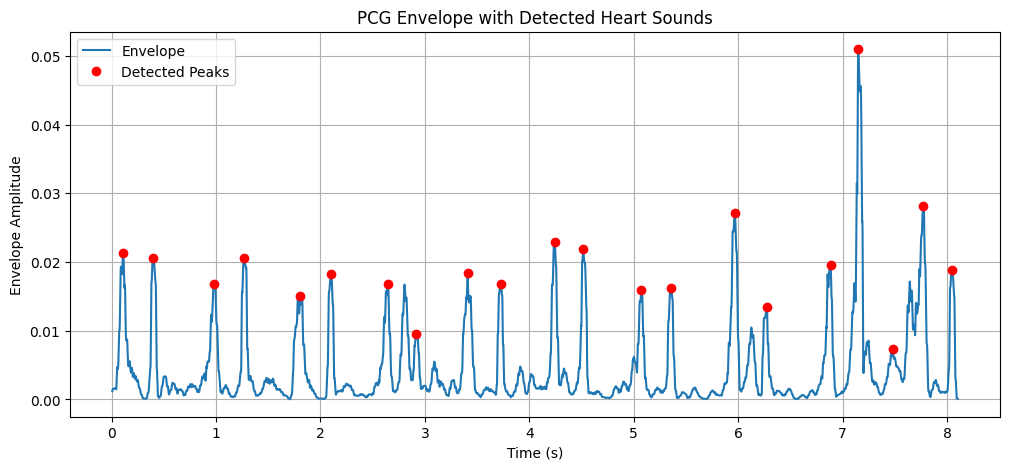

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))
plt.plot(pcg_time, envelope, label='Envelope')
plt.plot(pcg_time[peaks], envelope[peaks], 'ro', label='Detected Peaks')
plt.title('PCG Envelope with Detected Heart Sounds')
plt.xlabel('Time (s)')
plt.ylabel('Envelope Amplitude')
plt.legend()
plt.grid(True)
plt.show()


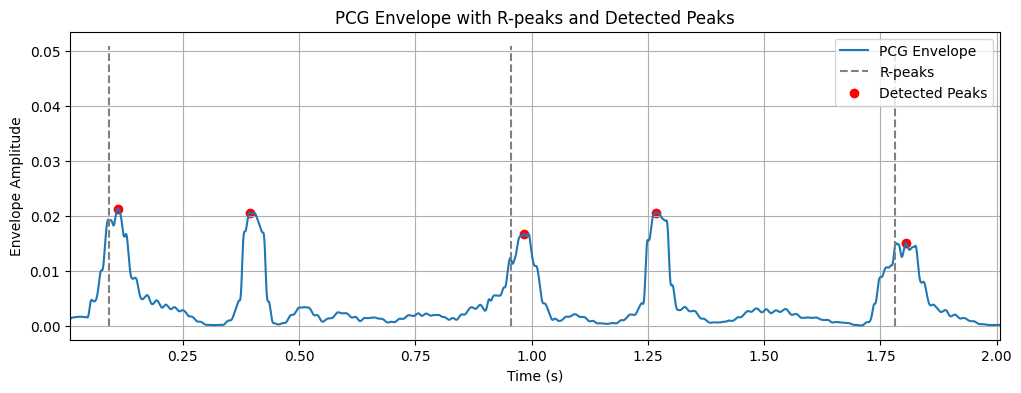

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 4))
plt.plot(pcg_time, envelope, label='PCG Envelope')
plt.vlines(rpeaks_times, ymin=0, ymax=max(envelope), color='gray', linestyle='--', label='R-peaks')
plt.scatter(pcg_time[peaks], envelope[peaks], color='red', label='Detected Peaks')
plt.xlim(pcg_time[0], pcg_time[0] + 2)  # First 2 seconds
plt.xlabel("Time (s)")
plt.ylabel("Envelope Amplitude")
plt.legend()
plt.grid(True)
plt.title("PCG Envelope with R-peaks and Detected Peaks")
plt.show()


In [ ]:
# First PCG peak time
first_pcg_peak_time = pcg_time[peaks[0]]
# First R-peak time
first_r_peak_time = rpeaks_times[0]

# Compute delay
delay = first_pcg_peak_time - first_r_peak_time
print(f"Delay from R-peak to first PCG peak: {delay*1000:.1f} ms")

# Decide label based on physiological window for S1
if 0.005 < delay < 0.150:
    first_is_s1 = True
    print("First PCG peak is S1.")
else:
    first_is_s1 = False
    print("First PCG peak is S2. The next one will be S1.")

Delay from R-peak to first PCG peak: 19.4 ms
First PCG peak is S1.


In [ ]:
if first_is_s1:
    s1_peaks = peaks[::2]
    s2_peaks = peaks[1::2]
else:
    s1_peaks = peaks[1::2]
    s2_peaks = peaks[::2]

s1_times = pcg_time[s1_peaks]
s2_times = pcg_time[s2_peaks]

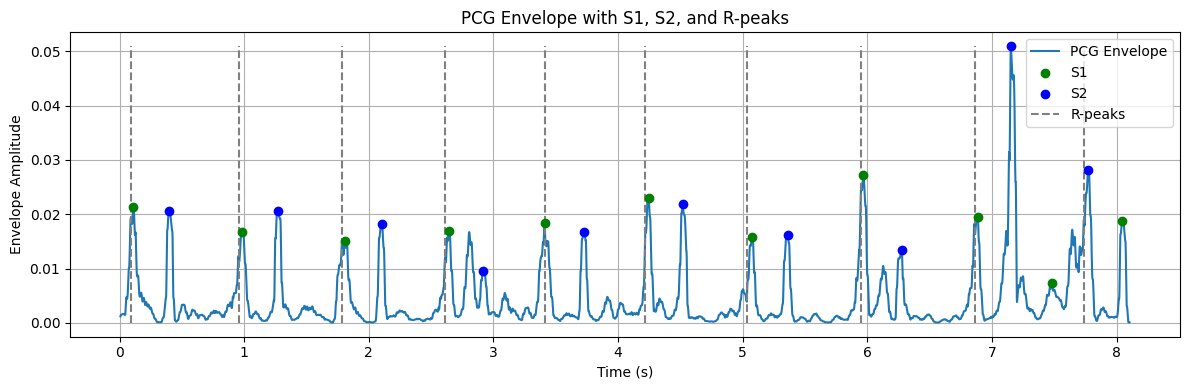

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 4))
plt.plot(pcg_time, envelope, label='PCG Envelope')

# Plot S1 peaks in green
plt.scatter(s1_times, np.interp(s1_times, pcg_time, envelope), color='green', label='S1', zorder=3)

# Plot S2 peaks in blue
plt.scatter(s2_times, np.interp(s2_times, pcg_time, envelope), color='blue', label='S2', zorder=3)

# plot R-peaks
plt.vlines(rpeaks_times, ymin=0, ymax=max(envelope), color='gray', linestyle='--', label='R-peaks')

plt.xlabel("Time (s)")
plt.ylabel("Envelope Amplitude")
plt.title("PCG Envelope with S1, S2, and R-peaks")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


<ipython-input-36-63249113d7ad>:15: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  plt.axvline(x=float(time_point), color='red', linestyle='--', label='AVO')
<ipython-input-36-63249113d7ad>:17: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  plt.axvline(x=float(time_point), color='purple', linestyle='--', label='AVC')
<ipython-input-36-63249113d7ad>:35: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  plt.axvline(x=float(time_point), color='red', linestyle='--', label='A

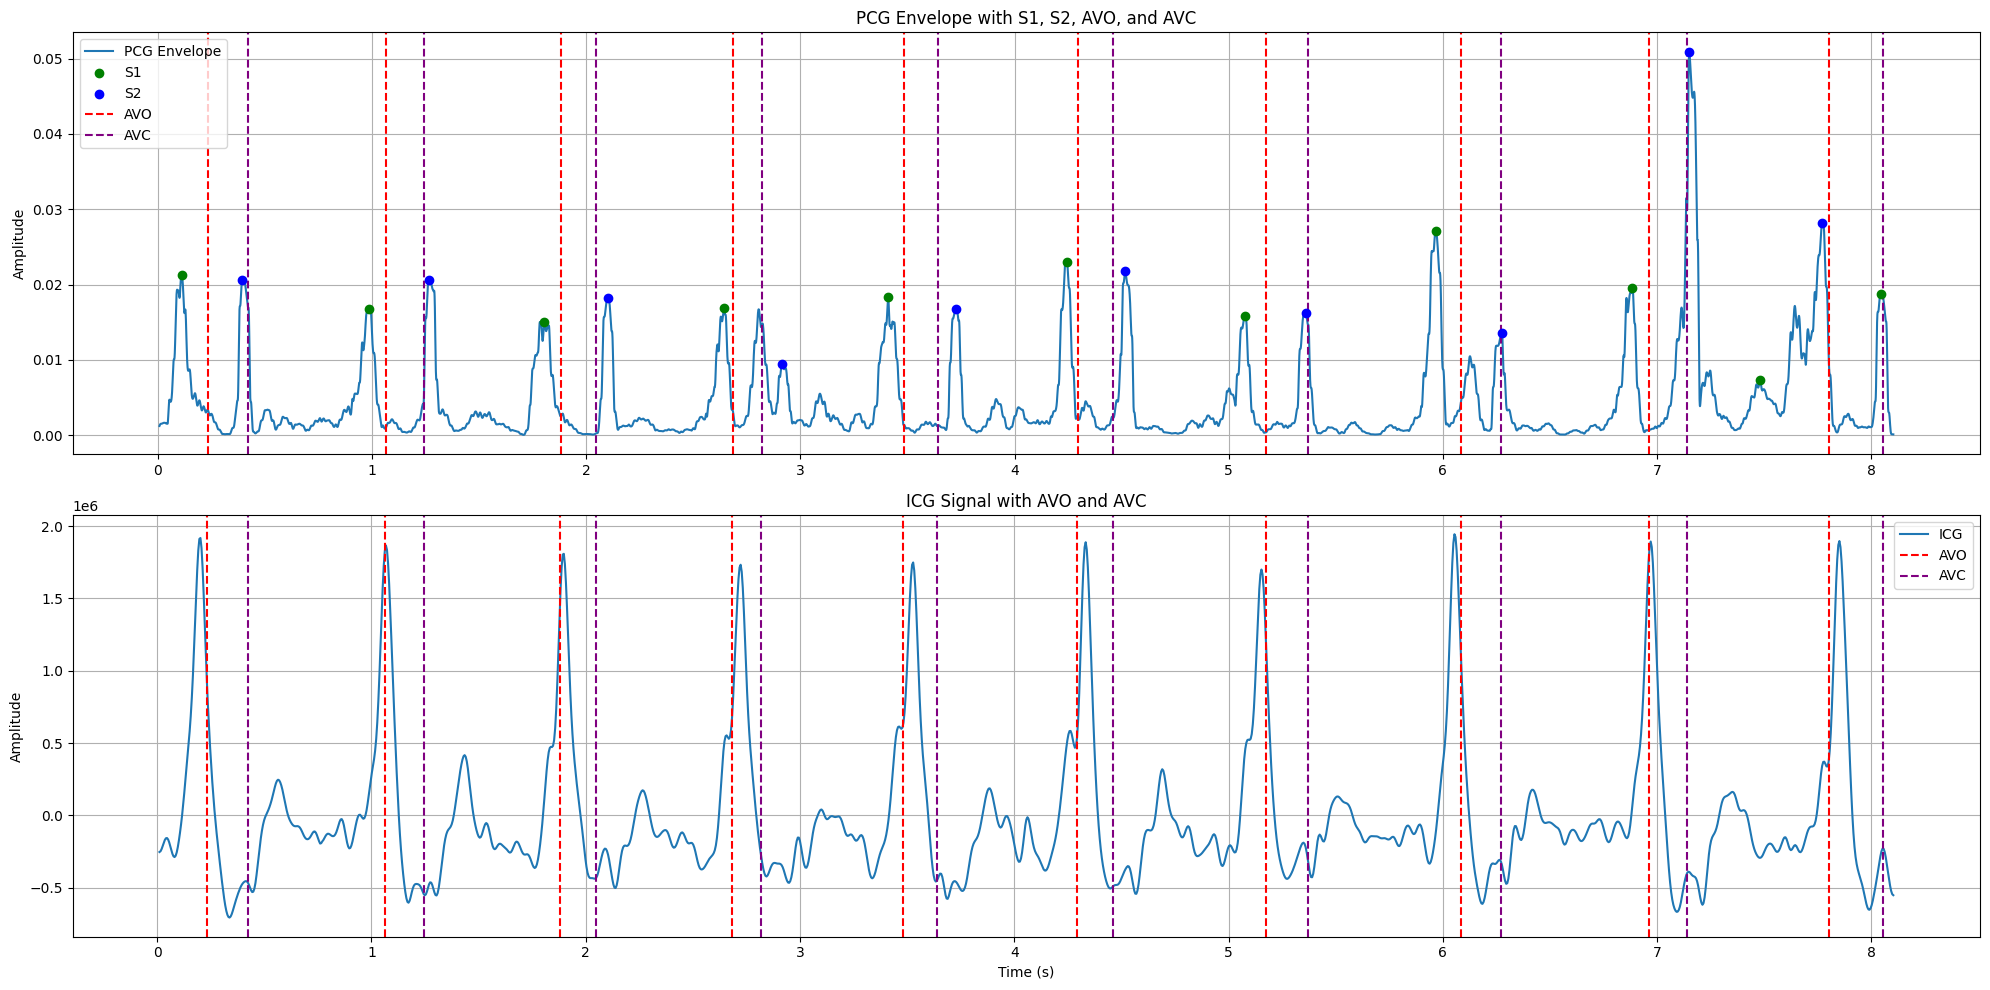

In [ ]:
plt.figure(figsize=(20, 10))

# ----------------------------
# Top: PCG Envelope + S1/S2 + AVO/AVC
# ----------------------------
plt.subplot(2, 1, 1)
plt.plot(pcg_time, envelope, label='PCG Envelope')

# Plot S1 and S2 points
plt.scatter(s1_times, np.interp(s1_times, pcg_time, envelope), color='green', label='S1', zorder=3)
plt.scatter(s2_times, np.interp(s2_times, pcg_time, envelope), color='blue', label='S2', zorder=3)

# Plot AVO and AVC
for time_point in avo_icg['data']:
    plt.axvline(x=float(time_point), color='red', linestyle='--', label='AVO')
for time_point in avc_icg['data']:
    plt.axvline(x=float(time_point), color='purple', linestyle='--', label='AVC')

plt.title('PCG Envelope with S1, S2, AVO, and AVC')
plt.ylabel('Amplitude')
plt.grid(True)

# Legend without duplicates
handles, labels = plt.gca().get_legend_handles_labels()
by_label = dict(zip(labels, handles))
plt.legend(by_label.values(), by_label.keys())

# ----------------------------
# Bottom: ICG with AVO/AVC
# ----------------------------
plt.subplot(2, 1, 2)
plt.plot(icg_time, dz_dt, label='ICG')

for time_point in avo_icg['data']:
    plt.axvline(x=float(time_point), color='red', linestyle='--', label='AVO')
for time_point in avc_icg['data']:
    plt.axvline(x=float(time_point), color='purple', linestyle='--', label='AVC')

plt.title('ICG Signal with AVO and AVC')
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.grid(True)

# Legend without duplicates
handles, labels = plt.gca().get_legend_handles_labels()
by_label = dict(zip(labels, handles))
plt.legend(by_label.values(), by_label.keys())

plt.tight_layout()
plt.show()


<ipython-input-37-951071e3436b>:27: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  plt.axvline(x=float(time_point), color='red', linestyle='--', label='AVO')
<ipython-input-37-951071e3436b>:29: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  plt.axvline(x=float(time_point), color='purple', linestyle='--', label='AVC')
<ipython-input-37-951071e3436b>:45: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  plt.axvline(x=float(time_point), color='red', linestyle='--', label='A

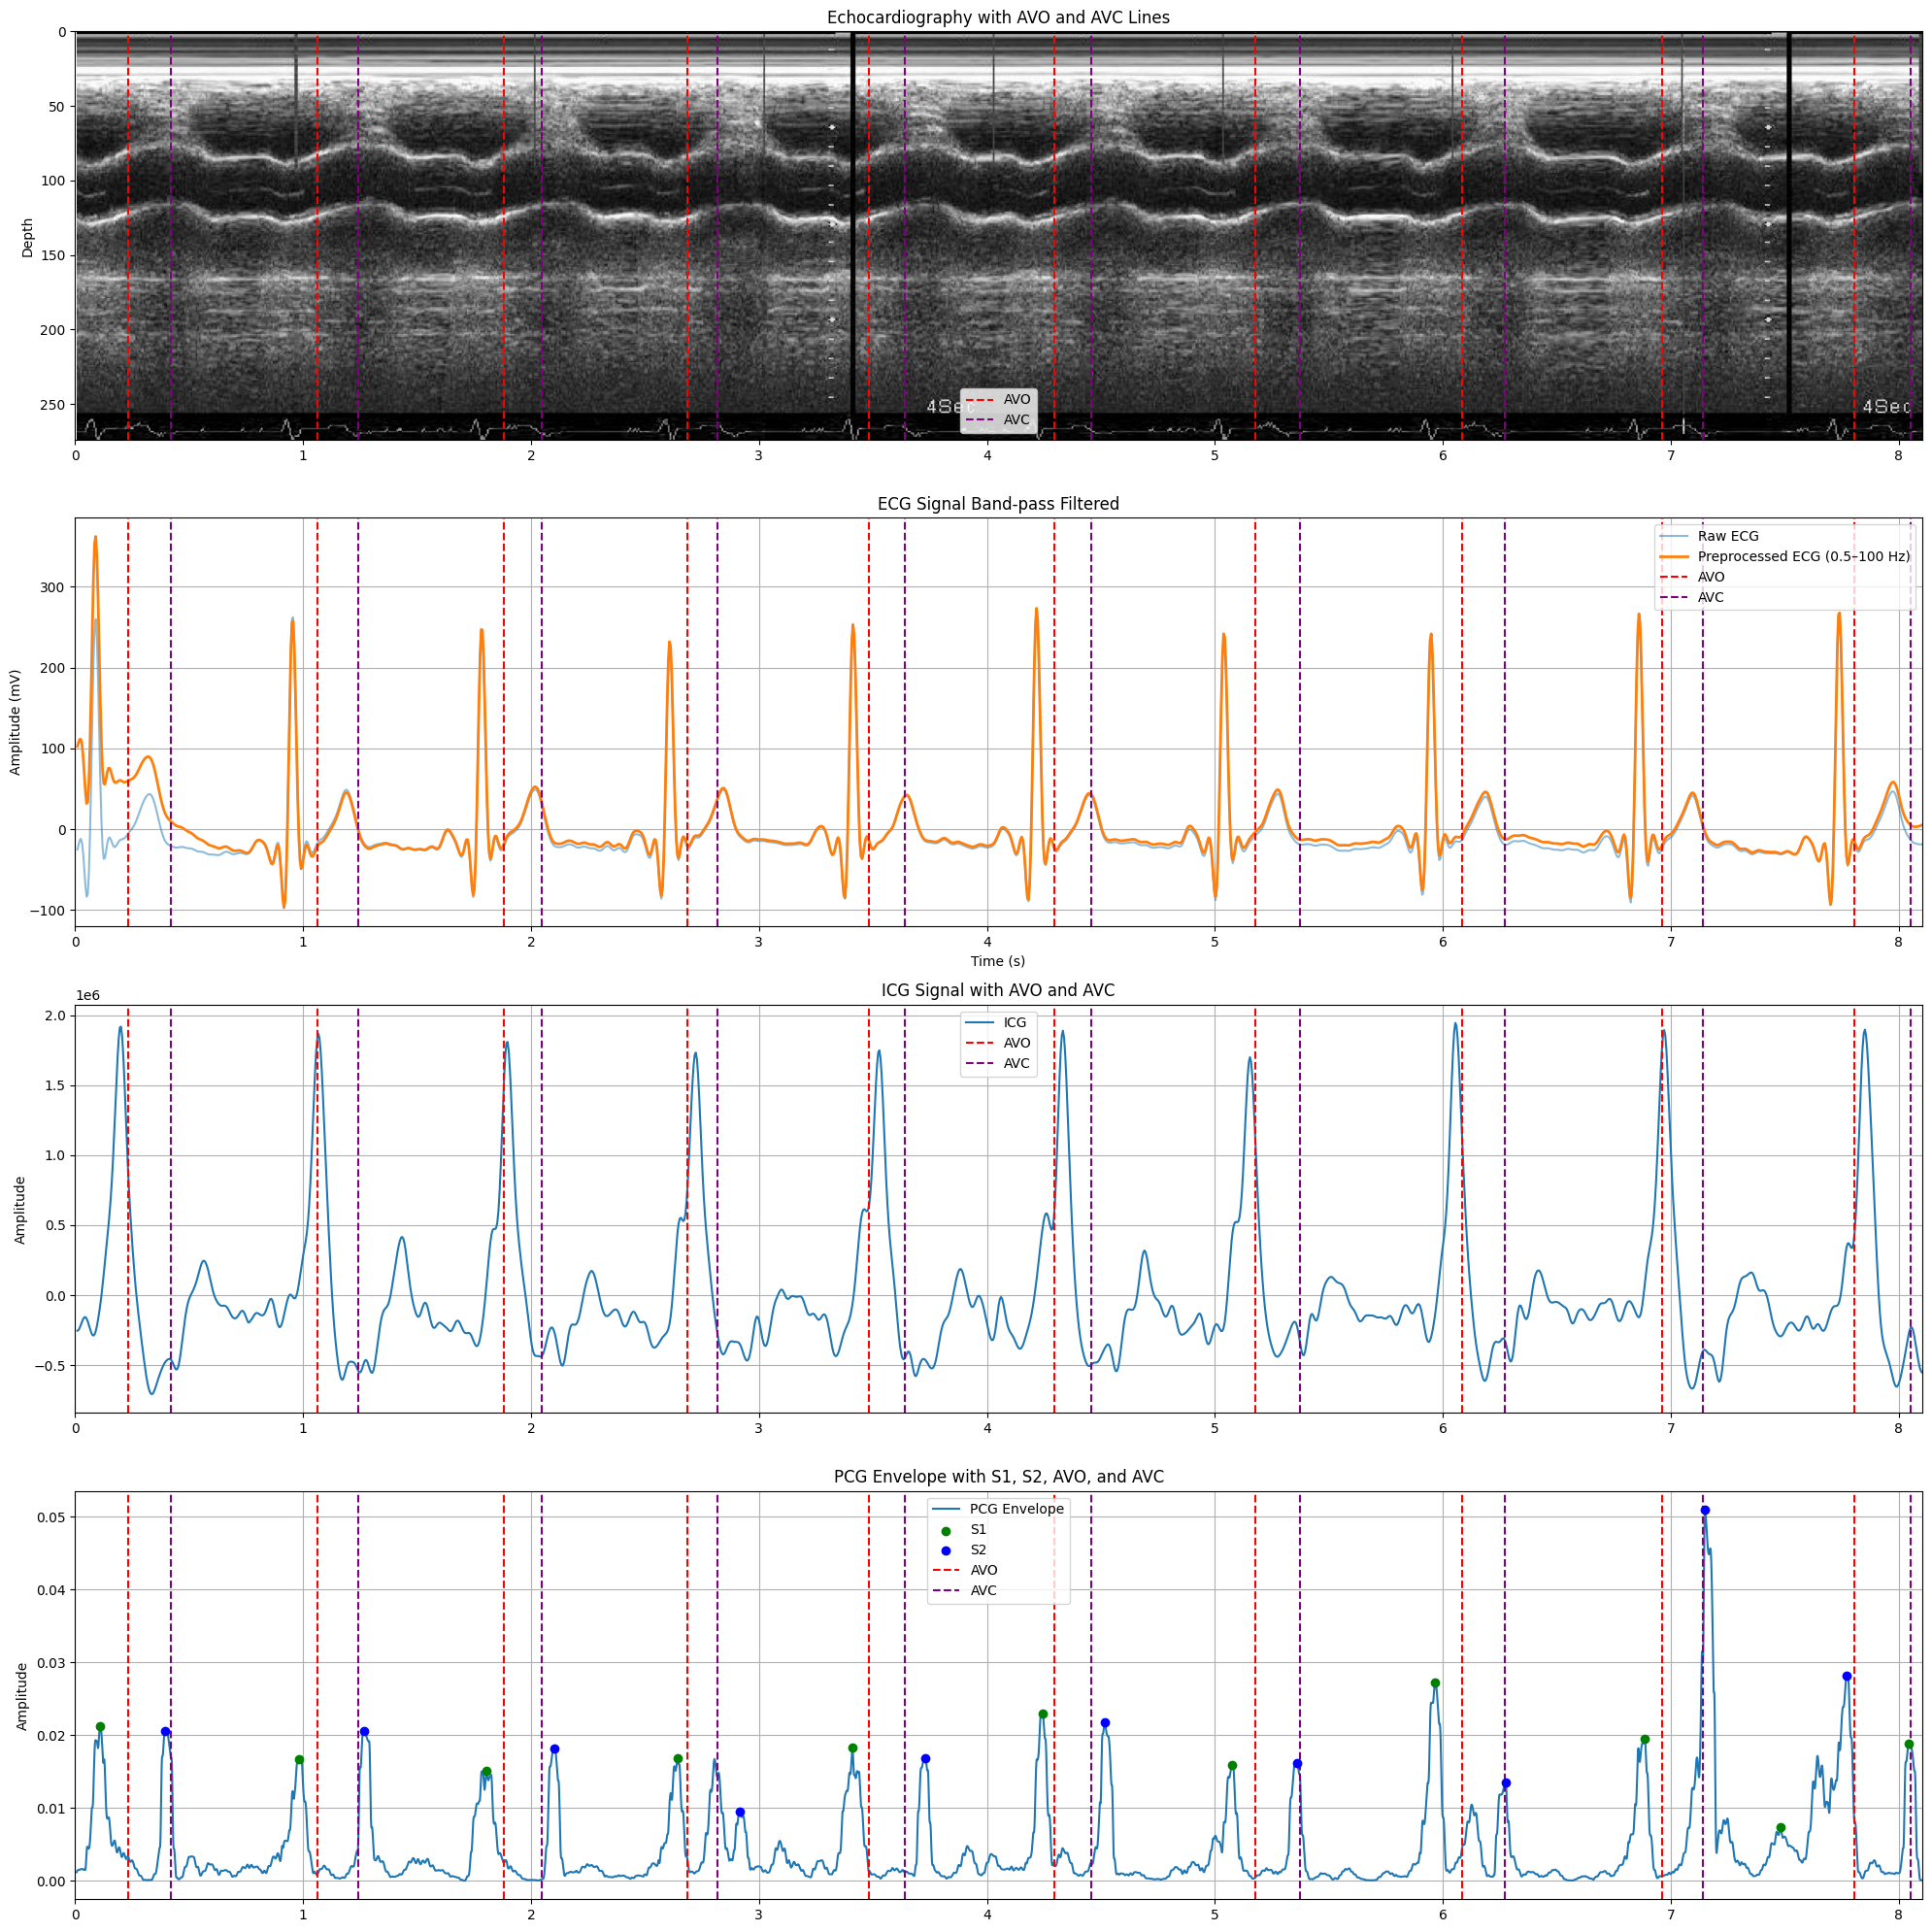

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# --------------------------------------------------
# Calculate common time limits across all signals
# --------------------------------------------------
common_start = 0  # Force all to start at 0
common_end = min(
    echo_really_flat[-1],
    pcg_time[-1],
    icg_time[-1],
    ecg_1_time[-1]
)

plt.figure(figsize=(20, 20))

# --------------------------------------------------
# 1. Echocardiography Image with AVO/AVC Lines
# --------------------------------------------------
plt.subplot(4, 1, 1)
plt.imshow(echo_value_1, aspect='auto', cmap='gray',
           extent=[echo_really_flat[0], echo_really_flat[-1], echo_value_1.shape[0], 0])
plt.title("Echocardiography with AVO and AVC Lines")
plt.ylabel("Depth")

for time_point in avo_icg['data']:
    plt.axvline(x=float(time_point), color='red', linestyle='--', label='AVO')
for time_point in avc_icg['data']:
    plt.axvline(x=float(time_point), color='purple', linestyle='--', label='AVC')

plt.xlim([common_start, common_end])
handles, labels = plt.gca().get_legend_handles_labels()
by_label = dict(zip(labels, handles))
plt.legend(by_label.values(), by_label.keys())
plt.grid(False)

# --------------------------------------------------
# 2. PCG Envelope with S1, S2, AVO, and AVC
# --------------------------------------------------
plt.subplot(4, 1, 2)
plt.plot(ecg_1_time, ecg_1_data, label='Raw ECG', alpha=0.5)
plt.plot(ecg_1_time, ecg_1_preprocessed, label='Preprocessed ECG (0.5–100 Hz)', linewidth=2)

for time_point in avo_icg['data']:
    plt.axvline(x=float(time_point), color='red', linestyle='--', label='AVO')
for time_point in avc_icg['data']:
    plt.axvline(x=float(time_point), color='purple', linestyle='--', label='AVC')

plt.title('ECG Signal Band-pass Filtered')
plt.xlabel('Time (s)')
plt.ylabel('Amplitude (mV)')
plt.xlim([common_start, common_end])
plt.grid(True)


handles, labels = plt.gca().get_legend_handles_labels()
by_label = dict(zip(labels, handles))
plt.legend(by_label.values(), by_label.keys())

# --------------------------------------------------
# 3. ICG Signal with AVO and AVC
# --------------------------------------------------
plt.subplot(4, 1, 3)
plt.plot(icg_time, dz_dt, label='ICG')

for time_point in avo_icg['data']:
    plt.axvline(x=float(time_point), color='red', linestyle='--', label='AVO')
for time_point in avc_icg['data']:
    plt.axvline(x=float(time_point), color='purple', linestyle='--', label='AVC')

plt.title('ICG Signal with AVO and AVC')
plt.ylabel('Amplitude')
plt.xlim([common_start, common_end])
plt.grid(True)

handles, labels = plt.gca().get_legend_handles_labels()
by_label = dict(zip(labels, handles))
plt.legend(by_label.values(), by_label.keys())

# --------------------------------------------------
# 4. ECG Signal (Raw and Preprocessed) with AVO/AVC
# --------------------------------------------------
plt.subplot(4, 1, 4)
plt.plot(pcg_time, envelope, label='PCG Envelope')

plt.scatter(s1_times, np.interp(s1_times, pcg_time, envelope), color='green', label='S1', zorder=3)
plt.scatter(s2_times, np.interp(s2_times, pcg_time, envelope), color='blue', label='S2', zorder=3)

for time_point in avo_icg['data']:
    plt.axvline(x=float(time_point), color='red', linestyle='--', label='AVO')
for time_point in avc_icg['data']:
    plt.axvline(x=float(time_point), color='purple', linestyle='--', label='AVC')

plt.title('PCG Envelope with S1, S2, AVO, and AVC')
plt.ylabel('Amplitude')
plt.xlim([common_start, common_end])
plt.grid(True)

handles, labels = plt.gca().get_legend_handles_labels()
by_label = dict(zip(labels, handles))
plt.legend(by_label.values(), by_label.keys())

plt.tight_layout()
plt.show()


https://www.jstage.jst.go.jp/article/ihj1960/18/1/18_1_81/_article/-char/ja/
this paper says "It was observed that the second component of the first heart sound grossly coincides with the opening of the aortic valve.
The aortic component of the second sound starts a few milliseconds after aortic valve closure"

<ipython-input-38-948d6a33d1f7>:7: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  plt.axvline(x=float(time_point), color='red', linestyle='--', label='AVO')
<ipython-input-38-948d6a33d1f7>:9: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  plt.axvline(x=float(time_point), color='purple', linestyle='--', label='AVC')


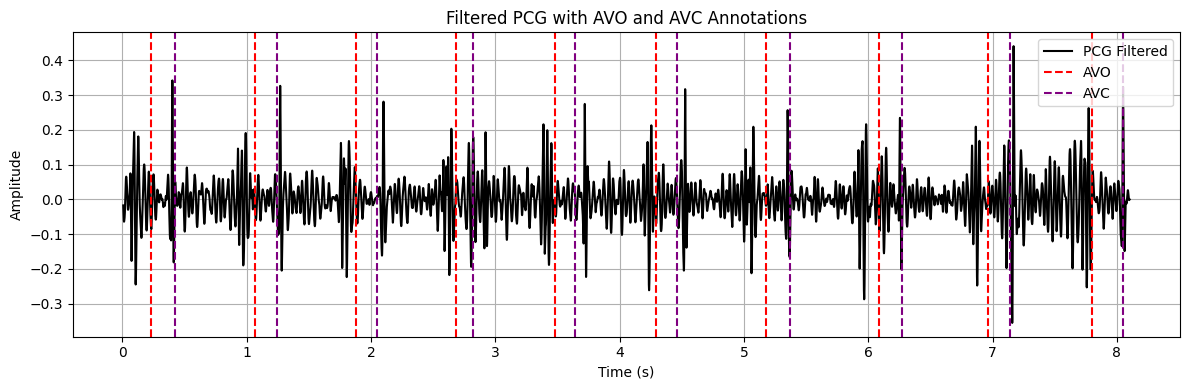

In [ ]:
plt.figure(figsize=(12, 4))

plt.plot(pcg_time, pcg_filtered, label='PCG Filtered', color='black')

# Overlay AVO and AVC annotations
for time_point in avo_icg['data']:
    plt.axvline(x=float(time_point), color='red', linestyle='--', label='AVO')
for time_point in avc_icg['data']:
    plt.axvline(x=float(time_point), color='purple', linestyle='--', label='AVC')

plt.title('Filtered PCG with AVO and AVC Annotations')
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.grid(True)

# Legend without duplicates
handles, labels = plt.gca().get_legend_handles_labels()
by_label = dict(zip(labels, handles))
plt.legend(by_label.values(), by_label.keys())

plt.tight_layout()
plt.show()


<ipython-input-39-2aa8c59a2d6e>:11: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  plt.axvline(x=float(time_point), color='red', linestyle='--', label='AVO')
<ipython-input-39-2aa8c59a2d6e>:13: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  plt.axvline(x=float(time_point), color='purple', linestyle='--', label='AVC')


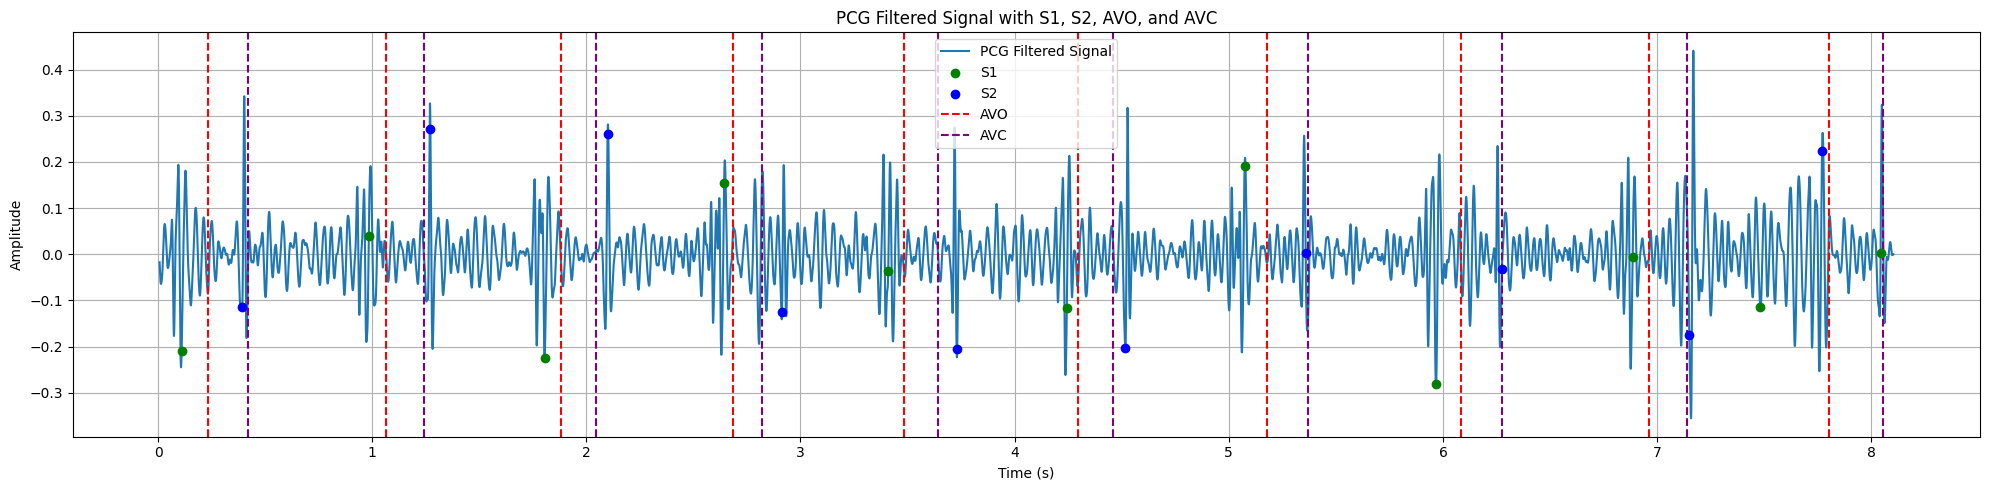

In [ ]:
plt.figure(figsize=(20, 5))

plt.plot(pcg_time, pcg_filtered, label='PCG Filtered Signal')

# Overlay S1 and S2
plt.scatter(s1_times, np.interp(s1_times, pcg_time, pcg_filtered), color='green', label='S1', zorder=3)
plt.scatter(s2_times, np.interp(s2_times, pcg_time, pcg_filtered), color='blue', label='S2', zorder=3)

# Overlay AVO and AVC
for time_point in avo_icg['data']:
    plt.axvline(x=float(time_point), color='red', linestyle='--', label='AVO')
for time_point in avc_icg['data']:
    plt.axvline(x=float(time_point), color='purple', linestyle='--', label='AVC')

plt.title('PCG Filtered Signal with S1, S2, AVO, and AVC')
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.grid(True)

# Legend without duplicates
handles, labels = plt.gca().get_legend_handles_labels()
by_label = dict(zip(labels, handles))
plt.legend(by_label.values(), by_label.keys())

plt.tight_layout()
plt.show()
